## QBUS2820 Assignment 1 — QSR Revenue Prediction
**SID:** 530377104

**Notebook structure** (mirrors the report):
- Section 2 — Exploratory Data Analysis (cells 4 to 100)
- Section 3 — Feature Engineering (cells 101 to 112)
- Section 4 — Modelling and Selection (cells 113 to 128)
- Final cell — Marker template (reads Test.csv, prints MSE)

**Reproducibility:** `SEED = 42` is used in every model and CV split.

**Required packages**: pip install `numpy, pandas, matplotlib, scipy, seaborn, scikit-learn`

In [1]:
# Importing Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats


In [2]:
# Load the Dataset
train_df = pd.read_csv("Training.csv")
test_df = pd.read_csv("Test_noLabel.csv")

In [3]:
train_df.head()

,OutletID,Date,Weekday,Month,Downtown,Mall,HighIncomeArea,OfficesNearby,CompetitorsNearby,Promo,EventNearby,Rain_mm,LagHigh,Revenue
0,9,2025-05-12,1,5,0,0,0.0,2.0,5.0,0,0,0.0,0,0.698727
1,65,2025-04-22,1,4,1,0,0.0,2.8,1.0,0,0,0.0,0,2.143487
2,16,2025-08-20,1,8,1,0,1.0,2.2,12.0,0,0,24.9,1,0.726108
3,88,2025-07-25,1,7,0,0,0.0,1.5,6.0,1,0,0.0,0,0.711227
4,100,2025-05-06,1,5,0,0,1.0,2.7,6.0,0,0,0.0,1,1.162186


# ============================================================
# SECTION 2: EXPLORATORY DATA ANALYSIS
# ============================================================


## ---- Section 2.1: Dataset Overview ----

Review data types, shape, and non-null counts to understand the dataset structure. This subsection corresponds to report Section 2.1.

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3456 entries, 0 to 3455
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OutletID           3456 non-null   int64  
 1   Date               3456 non-null   str    
 2   Weekday            3456 non-null   int64  
 3   Month              3456 non-null   int64  
 4   Downtown           3456 non-null   int64  
 5   Mall               3456 non-null   int64  
 6   HighIncomeArea     3410 non-null   float64
 7   OfficesNearby      3393 non-null   float64
 8   CompetitorsNearby  3414 non-null   float64
 9   Promo              3456 non-null   int64  
 10  EventNearby        3456 non-null   int64  
 11  Rain_mm            3363 non-null   float64
 12  LagHigh            3456 non-null   int64  
 13  Revenue            3456 non-null   float64
dtypes: float64(5), int64(8), str(1)
memory usage: 378.1 KB


In [5]:
# How many rows and columns?
train_df.shape 

(3456, 14)

In [6]:
# What types are our variables?
train_df.dtypes

OutletID               int64
Date                     str
Weekday                int64
Month                  int64
Downtown               int64
Mall                   int64
HighIncomeArea       float64
OfficesNearby        float64
CompetitorsNearby    float64
Promo                  int64
EventNearby            int64
Rain_mm              float64
LagHigh                int64
Revenue              float64
dtype: object

In [7]:
# Confirming to see whether Revenue is continous and measured in thousands of dollars
train_df["Revenue"]

0       0.698727
1       2.143487
2       0.726108
3       0.711227
4       1.162186
          ...   
3451    0.546186
3452    2.356662
3453    1.029866
3454    1.167404
3455    1.904658
Name: Revenue, Length: 3456, dtype: float64

## ---- Section 2.2: Target Variable (Revenue) ----

Revenue is continuous (float64) measured in thousands of dollars. A value of 0.698 represents $698 in daily outlet revenue. This subsection corresponds to report Section 2.2 and produces Figure 1 and Table 1.

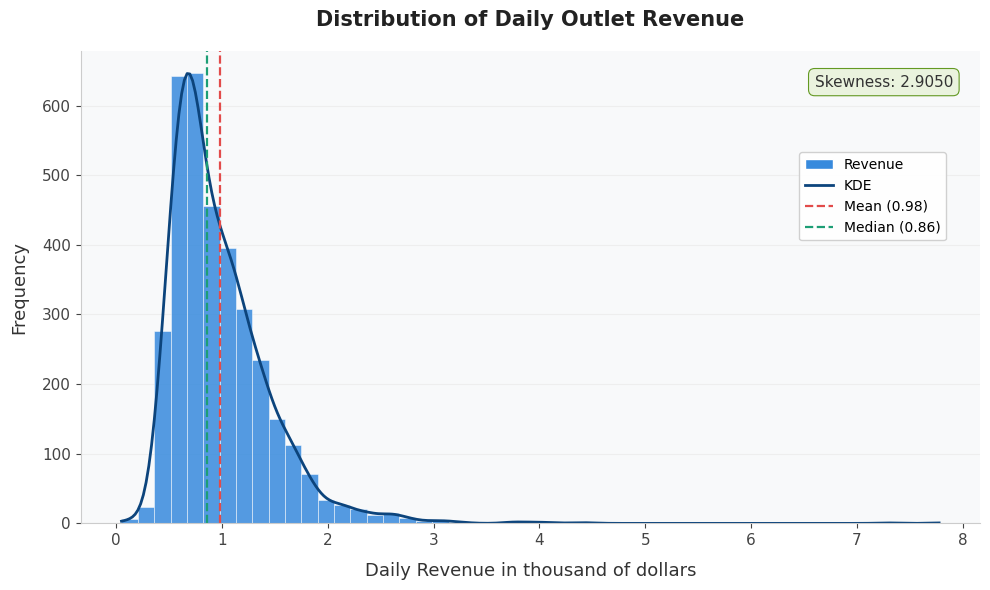

In [8]:
# Plotting a histogram to check for skewness in revenue  
fig, ax = plt.subplots(figsize=(10, 6))

# Data
revenue = train_df["Revenue"].dropna()
skewness = revenue.skew()
mean_val = revenue.mean()
median_val = revenue.median()

# Histogram
n, bins, patches = ax.hist(revenue, bins=50, color="#378ADD", alpha=0.85, edgecolor="white", linewidth=0.4)

# KDE overlay
kde_x = np.linspace(revenue.min(), revenue.max(), 300)
kde = stats.gaussian_kde(revenue)
kde_y = kde(kde_x) * len(revenue) * (bins[1] - bins[0])
ax.plot(kde_x, kde_y, color="#0C447C", linewidth=2)

# Mean and median lines
ax.axvline(mean_val, color="#E24B4A", linewidth=1.6, linestyle="--")
ax.axvline(median_val, color="#1D9E75", linewidth=1.6, linestyle="--")

# Styling
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors="#444444", labelsize=11)
ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Labels
ax.set_xlabel("Daily Revenue in thousand of dollars", fontsize=13, color="#333333", labelpad=10)
ax.set_ylabel("Frequency", fontsize=13, color="#333333", labelpad=10)
ax.set_title("Distribution of Daily Outlet Revenue", fontsize=15, fontweight="bold", color="#222222", pad=18)

# Skewness annotation box
ax.text(0.97, 0.95, f"Skewness: {skewness:.4f}",
        transform=ax.transAxes, fontsize=11, color="#333333",
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#EAF3DE", edgecolor="#639922", linewidth=0.8))

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#378ADD", edgecolor="white", label="Revenue"),
    plt.Line2D([0], [0], color="#0C447C", linewidth=2, label="KDE"),
    plt.Line2D([0], [0], color="#E24B4A", linewidth=1.6, linestyle="--", label=f"Mean ({mean_val:.2f})"),
    plt.Line2D([0], [0], color="#1D9E75", linewidth=1.6, linestyle="--", label=f"Median ({median_val:.2f})"),
]
ax.legend(handles=legend_elements, fontsize=10, framealpha=0.9,
          edgecolor="#CCCCCC", loc="upper right", bbox_to_anchor=(0.97, 0.80))

plt.tight_layout()
plt.savefig("revenue_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Section 2.2 - Interpretation:** Distribution is right-skewed (skewness = 2.9050). Mean ($0.9842k) sits above median ($0.8639k), driven by a small number of high-revenue outlet-days. The min of $52.60 and max of $7,775 are flagged as extreme.

In [9]:
# Section 2.2 - Revenue summary statistics (Table 1 in report)
rev = train_df['Revenue']

q1  = rev.quantile(0.25)
q3  = rev.quantile(0.75)
iqr = q3 - q1

summary = {
    'Mean'  : rev.mean(),
    'Median': rev.median(),
    'Std'   : rev.std(),
    'Min'   : rev.min(),
    'Max'   : rev.max(),
    'Q1'    : q1,
    'Q3'    : q3,
    'IQR'   : iqr,
}

print("Revenue Summary Statistics")
print("=" * 32)
for stat, val in summary.items():
    print(f"  {stat:<8} {val:.4f}")

Revenue Summary Statistics
  Mean     0.9842
  Median   0.8639
  Std      0.4885
  Min      0.0526
  Max      7.7753
  Q1       0.6528
  Q3       1.1996
  IQR      0.5468


**Section 2.2 - Key statistics:** Mean = 0.9842, Median = 0.8639, Std = 0.4885, Min = 0.0526, Max = 7.7753, IQR = 0.5468, Skewness = 2.9050. Mean exceeding the median confirms right skew.

In [10]:
# Section 2.2 - Flag Revenue outliers using IQR rule (1.5 * IQR)
lower = q1 - 1.5 * iqr 
upper = q3 + 1.5 * iqr

low_outliers = train_df[train_df['Revenue'] < lower]
high_outliers = train_df[train_df['Revenue'] > upper]
print(f"Lower fence : {lower:.4f}")
print(f"Upper fence : {upper:.4f}")
print(f"Low outliers : {len(low_outliers)}")
print(f"High outliers: {len(high_outliers)}")

Lower fence : -0.1675
Upper fence : 2.0199
Low outliers : 0
High outliers: 111


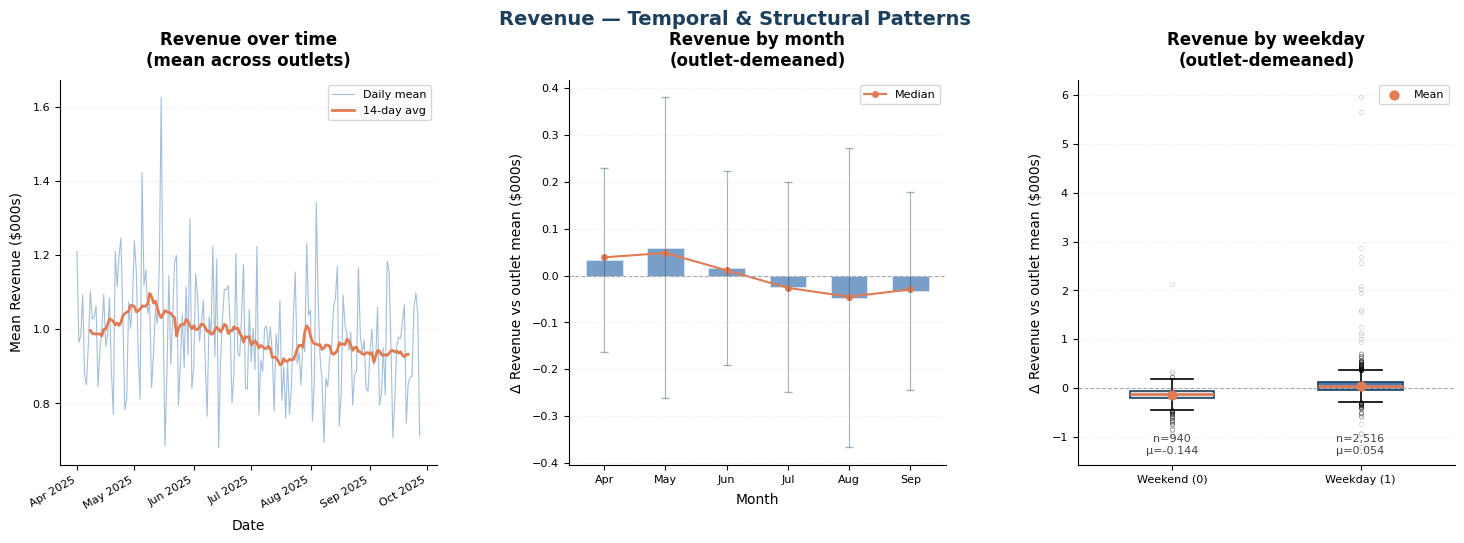

In [11]:
# Section 2.3 - Temporal patterns: revenue over time, by month, by weekday (Figure 2 in report)
# Panels 2 and 3 use outlet-demeaned Revenue to isolate pure time effects
# Helper columns 'outlet_mean' and 'Revenue_demeaned' are temporary and dropped in the EDA cleanup cell


train_df['Date'] = pd.to_datetime(train_df['Date'])
fig = plt.figure(figsize=(18, 5), facecolor='white')
gs = gridspec.GridSpec(1, 3, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

bar_color   = '#4A7FB5'
line_color  = '#1C3F5E'
mean_color  = '#E07B54'
median_color= '#5BAD8F'

# ── 1. Revenue over time (mean across outlets per day) ────────────
daily = train_df.groupby('Date')['Revenue'].mean().reset_index()
daily = daily.sort_values('Date')
daily['rolling'] = daily['Revenue'].rolling(14, center=True).mean()

ax1.plot(daily['Date'], daily['Revenue'],
         color=bar_color, linewidth=0.8, alpha=0.5, label='Daily mean')
ax1.plot(daily['Date'], daily['rolling'],
         color=mean_color, linewidth=2, label='14-day avg')
ax1.set_title('Revenue over time\n(mean across outlets)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Date', fontsize=10, labelpad=6)
ax1.set_ylabel('Mean Revenue ($000s)', fontsize=10, labelpad=6)
ax1.legend(fontsize=8)
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(labelsize=8)
ax1.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
ax1.set_axisbelow(True)
# Replace fig.autofmt_xdate with this more controlled version
ax1.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

# ── 2. Revenue by Month — demeaned per outlet ────────────────────
# subtract each outlet's own mean so we isolate the month effect
train_df['outlet_mean']     = train_df.groupby('OutletID')['Revenue'].transform('mean')
train_df['Revenue_demeaned']= train_df['Revenue'] - train_df['outlet_mean']

month_stats = train_df.groupby('Month')['Revenue_demeaned'].agg(
    ['mean','median','std']).reset_index()
x = month_stats['Month'].values
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
tick_labels  = [month_labels[m-1] for m in x]

ax2.bar(x, month_stats['mean'], color=bar_color,
        alpha=0.75, edgecolor='white', linewidth=0.4, width=0.6)
ax2.plot(x, month_stats['median'], color=mean_color,
         marker='o', markersize=4, linewidth=1.5, label='Median')
ax2.errorbar(x, month_stats['mean'], yerr=month_stats['std'],
             fmt='none', color=line_color, capsize=3,
             linewidth=0.8, alpha=0.4)
ax2.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(tick_labels, fontsize=8)
ax2.set_title('Revenue by month\n(outlet-demeaned)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Month', fontsize=10, labelpad=6)
ax2.set_ylabel('Δ Revenue vs outlet mean ($000s)', fontsize=10, labelpad=6)
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(labelsize=8)
ax2.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
ax2.set_axisbelow(True)

# ── 3. Revenue by Weekday — demeaned per outlet ──────────────────
groups = [
    train_df[train_df['Weekday']==0]['Revenue_demeaned'].dropna(),
    train_df[train_df['Weekday']==1]['Revenue_demeaned'].dropna()
]
labels  = ['Weekend (0)', 'Weekday (1)']
colors  = ['#D6E4F0', '#4A7FB5']

bp = ax3.boxplot(groups, patch_artist=True, widths=0.45,
                 boxprops    =dict(linewidth=1.2),
                 medianprops =dict(color=mean_color, linewidth=2),
                 whiskerprops=dict(linewidth=1.2),
                 capprops    =dict(linewidth=1.2),
                 flierprops  =dict(marker='o', alpha=0.3,
                                   markersize=3, markeredgewidth=0.3))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(line_color)

means = [g.mean() for g in groups]
ax3.scatter([1,2], means, color=mean_color, zorder=5, s=40, label='Mean')
ax3.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')

for i, (m, g) in enumerate(zip(means, groups), 1):
    ax3.text(i, ax3.get_ylim()[0]*0.85,
             f'n={len(g):,}\nμ={m:.3f}',
             ha='center', fontsize=8, color='#444444')

ax3.set_xticks([1,2])
ax3.set_xticklabels(labels, fontsize=9)
ax3.set_title('Revenue by weekday\n(outlet-demeaned)', fontsize=12, fontweight='bold', pad=10)
ax3.set_ylabel('Δ Revenue vs outlet mean ($000s)', fontsize=10, labelpad=6)
ax3.legend(fontsize=8)
ax3.spines[['top','right']].set_visible(False)
ax3.tick_params(labelsize=8)
ax3.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
ax3.set_axisbelow(True)

fig.suptitle('Revenue — Temporal & Structural Patterns',
             fontsize=14, fontweight='bold', y=1.02, color='#1C3F5E')

plt.savefig('revenue_temporal.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# clean up helper columns
train_df.drop(columns=['outlet_mean', 'Revenue_demeaned'], inplace=True)

## ---- Section 2.3: Temporal Patterns ----

**Panel 1 (Revenue over time):** Clear downward trend April to September. 14-day rolling average declines from ~$1.05k to ~$0.90k.

**Panel 2 (Revenue by month, outlet-demeaned):** April and May above-outlet-average (+$0.05k). July through September below average (-$0.05k to -$0.06k). Wide error bars show outlet-to-outlet variability within months.

**Panel 3 (Revenue by weekday, outlet-demeaned):** Weekdays +$0.054k above each outlet's baseline. Weekends -$0.144k below. The ~$0.20k gap is economically meaningful.

These findings motivate the DaysSinceStart feature in Section 3.

In [12]:
# Section 2.4 - Quick missingness count per column
# How many missing values per column?
train_df.isnull().sum()

OutletID              0
Date                  0
Weekday               0
Month                 0
Downtown              0
Mall                  0
HighIncomeArea       46
OfficesNearby        63
CompetitorsNearby    42
Promo                 0
EventNearby           0
Rain_mm              93
LagHigh               0
Revenue               0
dtype: int64

## ---- Section 2.4: Missingness ----

Compute missing count and percentage per column. Flag any column above 5% threshold. Results correspond to Table 2 in the report.

In [13]:
missing = pd.DataFrame({
    'Missing Count': train_df.isnull().sum(),
    'Missing %': (train_df.isnull().sum() / len(train_df) * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print("=== Missingness Table ===")
print(missing[missing['Missing Count'] > 0])

=== Missingness Table ===
                   Missing Count  Missing %
Rain_mm                       93       2.69
OfficesNearby                 63       1.82
HighIncomeArea                46       1.33
CompetitorsNearby             42       1.22


**Section 2.4 - Check:** Flag any column exceeding 5% missingness threshold.

In [14]:
# Section 2.4 - Flag columns with > 5% missing values
over5 = missing[missing['Missing %'] > 5]

if len(over5) > 0:
    print("Columns exceeding 5% missingness:")
    print(over5)
else:
    print("No columns exceed 5% missingness threshold — all safe.")

No columns exceed 5% missingness threshold — all safe.


**Section 2.4 - Check:** Does missingness cluster within specific outlets or date ranges?

In [15]:
# per outlet
train_df['n_missing'] = train_df.isnull().sum(axis=1)
outlet_missing = (train_df.groupby('OutletID')['n_missing']
                  .sum()
                  .sort_values(ascending=False))

print("=== Top 10 outlets by missing value count ===")
print(outlet_missing[outlet_missing > 0].head(10))

# per month
print("\n=== Missing values by month ===")
print(train_df.groupby('Month')['n_missing'].sum())

=== Top 10 outlets by missing value count ===
OutletID
74    6
2     5
14    5
7     5
34    5
84    5
60    5
39    5
67    5
94    5
Name: n_missing, dtype: int64

=== Missing values by month ===
Month
4    40
5    47
6    34
7    42
8    41
9    40
Name: n_missing, dtype: int64


**Section 2.4 - Check:** Test whether rows with missing values have different mean Revenue.

- MCAR (Missing Completely At Random) = no Revenue difference
- MAR (Missing At Random) = significant Revenue difference

In [16]:
# Section 2.4 - MAR vs MCAR test using two-sample t-test
# Result: p = 0.0012 (significant Revenue difference, classifies as MAR)


has_missing  = train_df['n_missing'] > 0
rev_missing  = train_df[has_missing]['Revenue'].dropna()
rev_complete = train_df[~has_missing]['Revenue'].dropna()

t_stat, p_val = stats.ttest_ind(rev_missing, rev_complete)

print("=== MAR vs MCAR check ===")
print(f"Mean Revenue (rows with missing) : {rev_missing.mean():.4f}")
print(f"Mean Revenue (complete rows)     : {rev_complete.mean():.4f}")
print(f"Difference                       : {rev_missing.mean() - rev_complete.mean():.4f}")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val:.4f}")
print()
if p_val < 0.05:
    print("Significant difference — missingness is likely MAR (not random).")
    print("Rows with missing values have systematically different Revenue.")
else:
    print("No significant difference — missingness is likely MCAR (random).")
    print("Safe to use median/mean imputation without introducing bias.")

=== MAR vs MCAR check ===
Mean Revenue (rows with missing) : 1.0830
Mean Revenue (complete rows)     : 0.9769
Difference                       : 0.1061
T-statistic : 3.2438
P-value     : 0.0012

Significant difference — missingness is likely MAR (not random).
Rows with missing values have systematically different Revenue.


**Section 2.4 - Check:** For numeric features with missing values, determine whether NaN may encode zero or 'not measured'.

In [17]:
print("=== Rain_mm ===")
print(f"  Missing : {train_df['Rain_mm'].isnull().sum()}")
print(f"  Zero    : {(train_df['Rain_mm'] == 0).sum()}")
print(f"  > 0     : {(train_df['Rain_mm'] > 0).sum()}")
print(f"  Note: {(train_df['Rain_mm'] == 0).sum()} zero entries already exist,")
print(f"        so NaN likely means 'not recorded', not necessarily a dry day.")

print("\n=== OfficesNearby ===")
print(f"  Missing : {train_df['OfficesNearby'].isnull().sum()}")
print(f"  Zero    : {(train_df['OfficesNearby'] == 0).sum()}")
print(f"  Min     : {train_df['OfficesNearby'].min()}")

print("\n=== CompetitorsNearby ===")
print(f"  Missing : {train_df['CompetitorsNearby'].isnull().sum()}")
print(f"  Zero    : {(train_df['CompetitorsNearby'] == 0).sum()}")
print(f"  Min     : {train_df['CompetitorsNearby'].min()}")

# check if missing OfficesNearby is consistent within an outlet
# (if it's always missing for the same outlet, it's structural)
offices_missing_outlets = (train_df[train_df['OfficesNearby'].isnull()]
                           ['OutletID'].value_counts())
print("\n=== Outlets where OfficesNearby is missing ===")
print(offices_missing_outlets)

=== Rain_mm ===
  Missing : 93
  Zero    : 1860
  > 0     : 1503
  Note: 1860 zero entries already exist,
        so NaN likely means 'not recorded', not necessarily a dry day.

=== OfficesNearby ===
  Missing : 63
  Zero    : 0
  Min     : 0.0705248606739343

=== CompetitorsNearby ===
  Missing : 42
  Zero    : 29
  Min     : 0.0

=== Outlets where OfficesNearby is missing ===
OutletID
84     4
34     3
63     2
17     2
81     2
14     2
38     2
6      1
40     1
44     1
37     1
33     1
82     1
10     1
73     1
96     1
43     1
16     1
89     1
23     1
83     1
19     1
3      1
88     1
74     1
15     1
69     1
20     1
62     1
48     1
106    1
116    1
112    1
2      1
27     1
26     1
118    1
9      1
93     1
18     1
39     1
108    1
4      1
5      1
101    1
42     1
65     1
56     1
79     1
71     1
64     1
97     1
66     1
Name: count, dtype: int64


In [18]:
# Section 2.4 - Missingness summary for report documentation
print("=== Missingness Summary (for report) ===")
print(f"Total rows          : {len(train_df)}")
print(f"Rows with any NaN   : {has_missing.sum()} ({has_missing.mean()*100:.1f}%)")
print()
for col in ['Rain_mm', 'OfficesNearby', 'CompetitorsNearby', 'HighIncomeArea']:
    n = train_df[col].isnull().sum()
    pct = n / len(train_df) * 100
    print(f"  {col:<20} {n:>3} missing ({pct:.2f}%)")
print()
print(""" 
Missingness shows no strong temporal or outlet-level clustering, 
however rows with missing values have significantly higher mean Revenue (p = 0.0012),
suggesting a MAR mechanism. Imputation will be performed within the modelling pipeline using outlet-level medians to account for this.
""")
# clean up helper column
train_df.drop(columns=['n_missing'], inplace=True)

=== Missingness Summary (for report) ===
Total rows          : 3456
Rows with any NaN   : 239 (6.9%)

  Rain_mm               93 missing (2.69%)
  OfficesNearby         63 missing (1.82%)
  CompetitorsNearby     42 missing (1.22%)
  HighIncomeArea        46 missing (1.33%)

 
Missingness shows no strong temporal or outlet-level clustering, 
however rows with missing values have significantly higher mean Revenue (p = 0.0012),
suggesting a MAR mechanism. Imputation will be performed within the modelling pipeline using outlet-level medians to account for this.



## ---- Section 2.5: Binary Features ----

Check value counts, near-constant risk, data integrity, mean Revenue by class, and Downtown vs Mall overlap. Results correspond to Figures 3 and 4 in the report.

In [19]:
# Section 2.5 - Value counts for all binary features
binary_cols = ['Weekday', 'Downtown', 'Mall', 'HighIncomeArea', 
               'Promo', 'EventNearby', 'LagHigh']

print("=== Value Counts for Binary Features ===\n")
for col in binary_cols:
    counts = train_df[col].value_counts(dropna=False).sort_index()
    pct    = (train_df[col].value_counts(dropna=False, normalize=True)
              .sort_index() * 100).round(2)
    print(f"  {col}")
    for val in counts.index:
        print(f"    {val} → {counts[val]:>5}  ({pct[val]:.2f}%)")
    print()

=== Value Counts for Binary Features ===

  Weekday
    0 →   940  (27.20%)
    1 →  2516  (72.80%)

  Downtown
    0 →  2629  (76.07%)
    1 →   827  (23.93%)

  Mall
    0 →  2717  (78.62%)
    1 →   739  (21.38%)

  HighIncomeArea
    0.0 →  2042  (59.09%)
    1.0 →  1368  (39.58%)
    nan →    46  (1.33%)

  Promo
    0 →  2822  (81.66%)
    1 →   634  (18.34%)

  EventNearby
    0 →  3136  (90.74%)
    1 →   320  (9.26%)

  LagHigh
    0 →  1995  (57.73%)
    1 →  1461  (42.27%)



**Section 2.5 - Check:** Flag any binary column with < 5% in either class (near-constant risk).

In [20]:
print("=== Near-Constant Check (< 5% in either class) ===\n")
for col in binary_cols:
    pct = train_df[col].value_counts(normalize=True) * 100
    min_pct = pct.min()
    flag = " ← FLAG" if min_pct < 5 else ""
    print(f"  {col:<20} min class = {min_pct:.2f}%{flag}")

=== Near-Constant Check (< 5% in either class) ===

  Weekday              min class = 27.20%
  Downtown             min class = 23.93%
  Mall                 min class = 21.38%
  HighIncomeArea       min class = 40.12%
  Promo                min class = 18.34%
  EventNearby          min class = 9.26%
  LagHigh              min class = 42.27%


**Section 2.5 - Check:** Verify all binary columns contain only 0 and 1 values. The dataset is anonymised so unexpected values must be ruled out.

In [21]:
print("=== Binary Integrity Check (expected values: 0 and 1 only) ===\n")
for col in binary_cols:
    unique_vals = sorted(train_df[col].dropna().unique())
    expected    = set([0, 1])
    actual      = set(unique_vals)
    status      = "OK" if actual <= expected else "UNEXPECTED VALUES FOUND"
    print(f"  {col:<20} unique values: {unique_vals}  → {status}")

=== Binary Integrity Check (expected values: 0 and 1 only) ===

  Weekday              unique values: [np.int64(0), np.int64(1)]  → OK
  Downtown             unique values: [np.int64(0), np.int64(1)]  → OK
  Mall                 unique values: [np.int64(0), np.int64(1)]  → OK
  HighIncomeArea       unique values: [np.float64(0.0), np.float64(1.0)]  → OK
  Promo                unique values: [np.int64(0), np.int64(1)]  → OK
  EventNearby          unique values: [np.int64(0), np.int64(1)]  → OK
  LagHigh              unique values: [np.int64(0), np.int64(1)]  → OK


**Section 2.5 - Plot:** Mean Revenue by binary feature, 0 vs 1 (Figure 3 in report). The delta shows the mean Revenue difference between classes. LagHigh and Downtown show the largest effects.

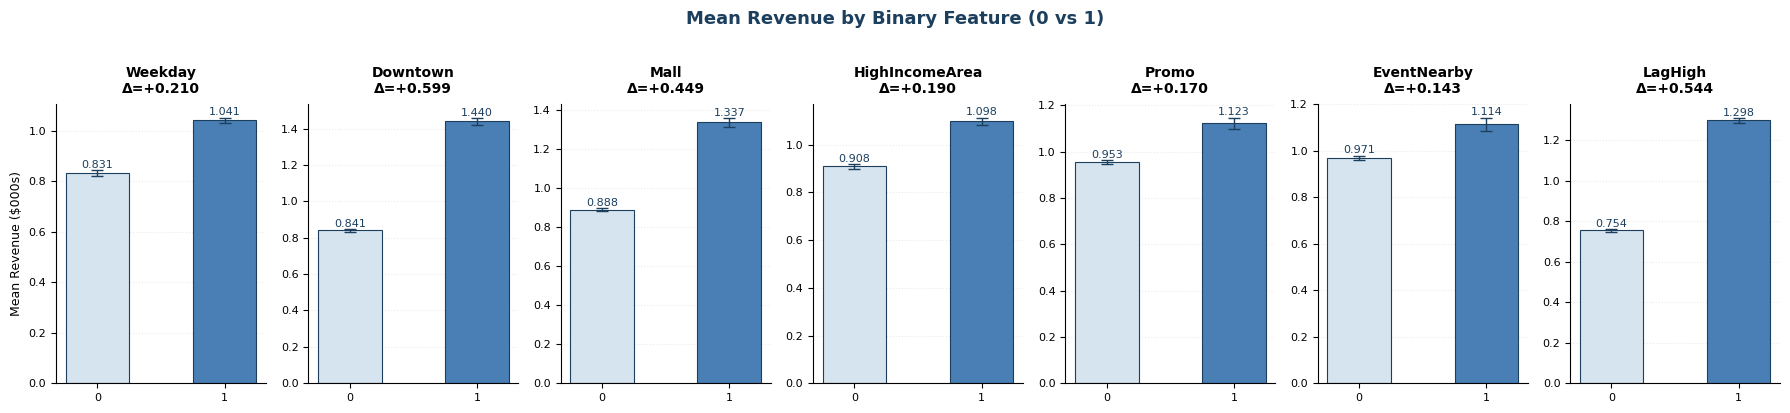

In [22]:
fig, axes = plt.subplots(1, len(binary_cols), figsize=(18, 4), facecolor='white')

bar_colors  = ['#D6E4F0', '#4A7FB5']
error_color = '#1C3F5E'
mean_color  = '#E07B54'

for ax, col in zip(axes, binary_cols):
    stats = train_df.groupby(col)['Revenue'].agg(['mean', 'std', 'count'])
    classes = stats.index.tolist()
    means   = stats['mean'].values
    sems    = (stats['std'] / np.sqrt(stats['count'])).values  # std error

    bars = ax.bar(
        [0, 1], means,
        color=bar_colors, edgecolor=error_color,
        linewidth=0.8, width=0.5
    )
    ax.errorbar(
        [0, 1], means, yerr=sems,
        fmt='none', color=error_color,
        capsize=4, linewidth=1
    )

    # annotate mean on each bar
    for i, (m, sem) in enumerate(zip(means, sems)):
        ax.text(i, m + sem + 0.01, f'{m:.3f}',
                ha='center', fontsize=8, color=error_color, fontweight='500')

    diff = means[1] - means[0] if len(means) == 2 else 0
    ax.set_title(f'{col}\nΔ={diff:+.3f}', fontsize=10,
                 fontweight='bold', pad=8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=9)
    ax.set_ylabel('Mean Revenue ($000s)' if col == binary_cols[0] else '',
                  fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8)

fig.suptitle('Mean Revenue by Binary Feature (0 vs 1)',
             fontsize=13, fontweight='bold', y=1.02, color='#1C3F5E')
plt.tight_layout()
plt.savefig('binary_revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**Section 2.5 - Check:** Downtown and Mall overlap analysis. Low Pearson r confirms they carry distinct signals and can both be retained.

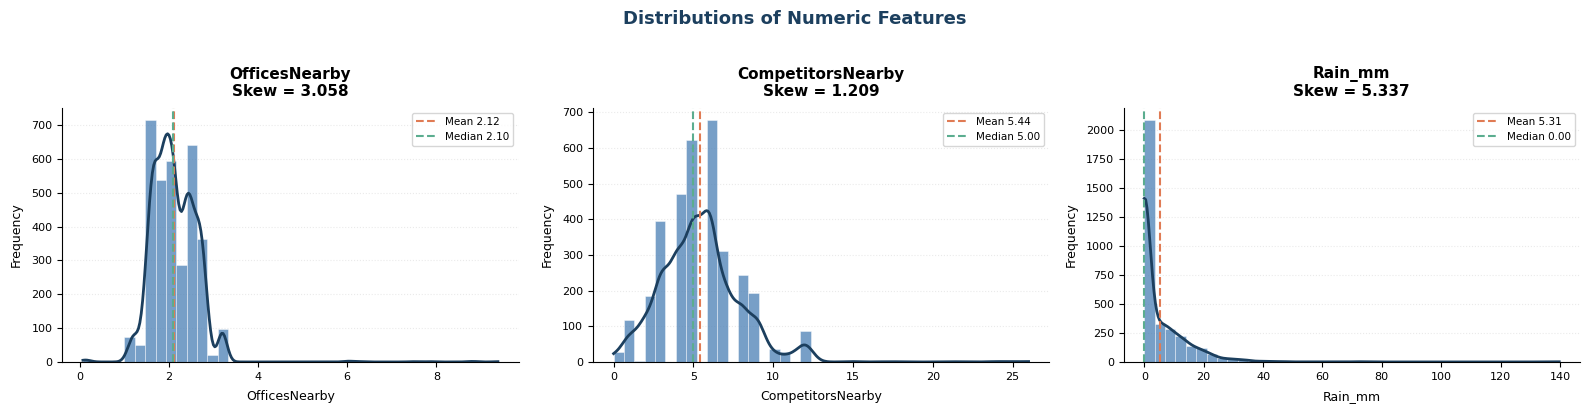

In [23]:
# Section 2.5 - Downtown vs Mall overlap and correlation check
from scipy import stats as scipy_stats

numeric_cols = ['OfficesNearby', 'CompetitorsNearby', 'Rain_mm']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

bar_color    = '#4A7FB5'
kde_color    = '#1C3F5E'
mean_color   = '#E07B54'
median_color = '#5BAD8F'

for ax, col in zip(axes, numeric_cols):
    data = train_df[col].dropna()

    n, bins, _ = ax.hist(data, bins=40, color=bar_color,
                         alpha=0.75, edgecolor='white', linewidth=0.4)

    kde_x = np.linspace(data.min(), data.max(), 300)
    kde   = scipy_stats.gaussian_kde(data)          # use scipy_stats not stats
    kde_y = kde(kde_x) * len(data) * (bins[1] - bins[0])
    ax.plot(kde_x, kde_y, color=kde_color, linewidth=2)

    ax.axvline(data.mean(),   color=mean_color,   linewidth=1.5,
               linestyle='--', label=f'Mean {data.mean():.2f}')
    ax.axvline(data.median(), color=median_color, linewidth=1.5,
               linestyle='--', label=f'Median {data.median():.2f}')

    skew = data.skew()
    ax.set_title(f'{col}\nSkew = {skew:.3f}', fontsize=11,
                 fontweight='bold', pad=8)
    ax.set_xlabel(col, fontsize=9, labelpad=6)
    ax.set_ylabel('Frequency', fontsize=9, labelpad=6)
    ax.legend(fontsize=7.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8)

fig.suptitle('Distributions of Numeric Features',
             fontsize=13, fontweight='bold', y=1.02, color='#1C3F5E')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150,
            bbox_inches='tight', facecolor='white')

## ---- Section 2.6: Numeric Features ----

Plot distributions for OfficesNearby, CompetitorsNearby, and Rain_mm. Check skewness, zero-inflation, and outliers. Results correspond to Figure 5 and Figure 6 in the report.

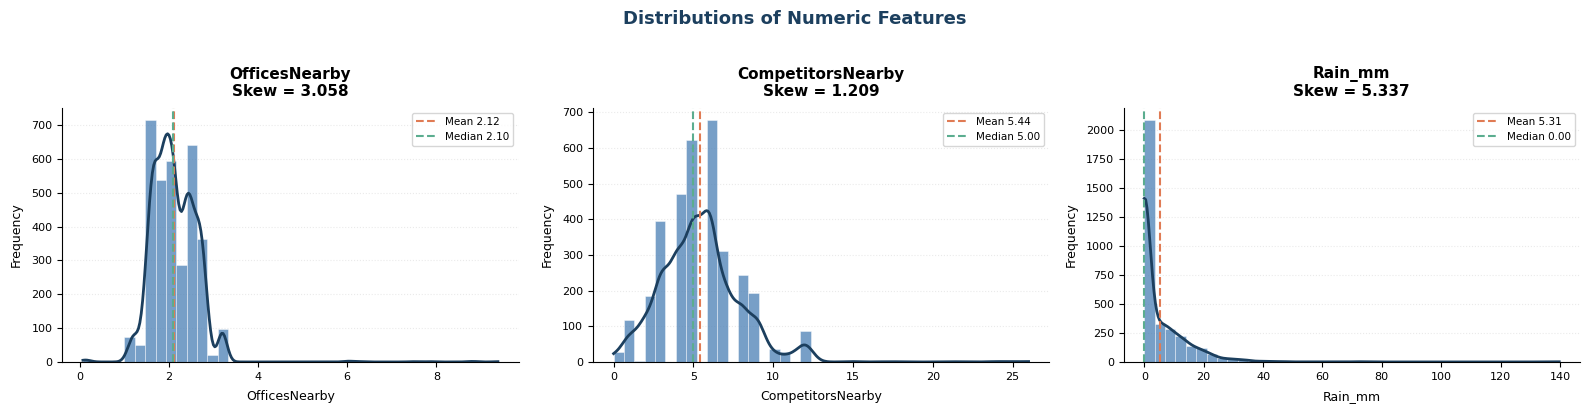

In [24]:
# Section 2.6 - Numeric feature distributions with KDE (Figure 5 in report)
from scipy import stats as scipy_stats

numeric_cols = ['OfficesNearby', 'CompetitorsNearby', 'Rain_mm']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

bar_color    = '#4A7FB5'
kde_color    = '#1C3F5E'
mean_color   = '#E07B54'
median_color = '#5BAD8F'

for ax, col in zip(axes, numeric_cols):
    data = train_df[col].dropna()

    n, bins, _ = ax.hist(data, bins=40, color=bar_color,
                         alpha=0.75, edgecolor='white', linewidth=0.4)

    kde_x = np.linspace(data.min(), data.max(), 300)
    kde   = scipy_stats.gaussian_kde(data)          # use scipy_stats not stats
    kde_y = kde(kde_x) * len(data) * (bins[1] - bins[0])
    ax.plot(kde_x, kde_y, color=kde_color, linewidth=2)

    ax.axvline(data.mean(),   color=mean_color,   linewidth=1.5,
               linestyle='--', label=f'Mean {data.mean():.2f}')
    ax.axvline(data.median(), color=median_color, linewidth=1.5,
               linestyle='--', label=f'Median {data.median():.2f}')

    skew = data.skew()
    ax.set_title(f'{col}\nSkew = {skew:.3f}', fontsize=11,
                 fontweight='bold', pad=8)
    ax.set_xlabel(col, fontsize=9, labelpad=6)
    ax.set_ylabel('Frequency', fontsize=9, labelpad=6)
    ax.legend(fontsize=7.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8)

fig.suptitle('Distributions of Numeric Features',
             fontsize=13, fontweight='bold', y=1.02, color='#1C3F5E')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

**Section 2.6 - Interpretation:**

- OfficesNearby (skew = 3.058): tightly clustered at 1.5 to 3.0, skew driven by extreme outlets.
- CompetitorsNearby (skew = 1.209): bimodal pattern around 5 and 12 competitors.
- Rain_mm (skew = 5.337): severe zero-inflation (55.3% dry days), max = 139.76mm. Replaced by RainToday and Rain_log1p in Section 3.

**Section 2.6 - Rain_mm zero-inflation check:**

In [25]:
# Section 2.6 - Rain_mm zero-inflation and skewness check
rain = train_df['Rain_mm'].dropna()

zero_count    = (rain == 0).sum()
nonzero_count = (rain > 0).sum()
zero_pct      = zero_count / len(rain) * 100

print("=== Rain_mm Zero-Inflation Check ===")
print(f"  Total non-missing : {len(rain)}")
print(f"  Zero (dry days)   : {zero_count} ({zero_pct:.1f}%)")
print(f"  Non-zero          : {nonzero_count} ({100 - zero_pct:.1f}%)")
print(f"  Skewness          : {rain.skew():.4f}")
print(f"  Mean              : {rain.mean():.4f}")
print(f"  Median            : {rain.median():.4f}")
print(f"  Max               : {rain.max():.4f}")
print()
if zero_pct > 40:
    print("Zero-inflated — consider engineering a binary 'RainToday' feature.")
if rain.skew() > 1:
    print("Right-skewed — consider log1p transform for non-zero values.")

=== Rain_mm Zero-Inflation Check ===
  Total non-missing : 3363
  Zero (dry days)   : 1860 (55.3%)
  Non-zero          : 1503 (44.7%)
  Skewness          : 5.3372
  Mean              : 5.3091
  Median            : 0.0000
  Max               : 139.7610

Zero-inflated — consider engineering a binary 'RainToday' feature.
Right-skewed — consider log1p transform for non-zero values.


**Section 2.6 - Outlier check:** IQR box plots for OfficesNearby and CompetitorsNearby.

**Section 2.6 - Check (cont.):** Outlier inspection for OfficesNearby and CompetitorsNearby using IQR method.

=== OfficesNearby IQR Outlier Summary ===
  Q1 = 1.8000, Q3 = 2.5000, IQR = 0.7000
  Lower fence = 0.7500, Upper fence = 3.5500
  Outliers flagged = 16
  Max value = 9.3822

=== CompetitorsNearby IQR Outlier Summary ===
  Q1 = 4.0000, Q3 = 7.0000, IQR = 3.0000
  Lower fence = -0.5000, Upper fence = 11.5000
  Outliers flagged = 99
  Max value = 26.0000



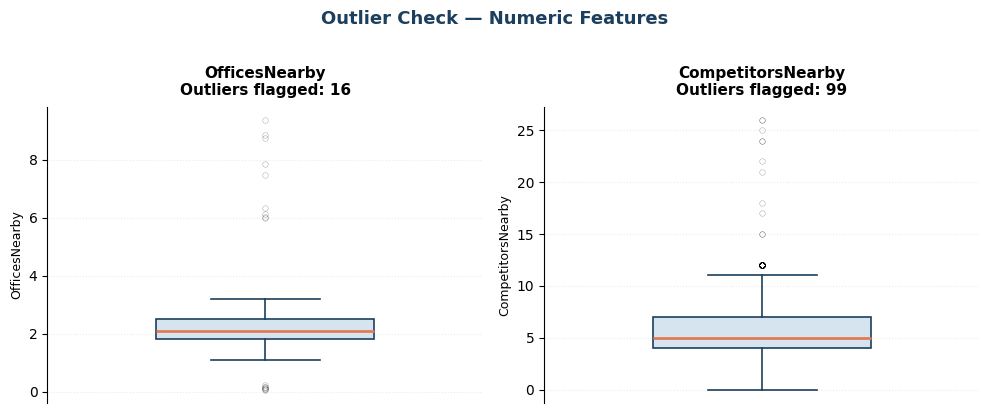

In [26]:
# Section 2.6 - Internal IQR box plots for OfficesNearby and CompetitorsNearby
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='white')
cols_to_check = ['OfficesNearby', 'CompetitorsNearby']

for ax, col in zip(axes, cols_to_check):
    data = train_df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    n_out  = ((data < lower) | (data > upper)).sum()

    bp = ax.boxplot(data, patch_artist=True, vert=True, widths=0.5,
                    boxprops    =dict(facecolor='#D6E4F0', color='#1C3F5E', linewidth=1.2),
                    medianprops =dict(color='#E07B54', linewidth=2),
                    whiskerprops=dict(color='#1C3F5E', linewidth=1.2),
                    capprops    =dict(color='#1C3F5E', linewidth=1.2),
                    flierprops  =dict(marker='o', color='#4A7FB5',
                                      alpha=0.4, markersize=4,
                                      markeredgewidth=0.3))

    ax.set_title(f'{col}\nOutliers flagged: {n_out}', fontsize=11,
                 fontweight='bold', pad=8)
    ax.set_ylabel(col, fontsize=9)
    ax.set_xticks([])
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)

    print(f"=== {col} IQR Outlier Summary ===")
    print(f"  Q1 = {q1:.4f}, Q3 = {q3:.4f}, IQR = {iqr:.4f}")
    print(f"  Lower fence = {lower:.4f}, Upper fence = {upper:.4f}")
    print(f"  Outliers flagged = {n_out}")
    print(f"  Max value = {data.max():.4f}\n")

fig.suptitle('Outlier Check — Numeric Features',
             fontsize=13, fontweight='bold', y=1.02, color='#1C3F5E')
plt.tight_layout()
plt.savefig('numeric_outliers.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

**Section 2.6 - Outlier interpretation:**

- OfficesNearby: 16 IQR outliers (0.47%), genuine extreme outlets in dense areas.
- CompetitorsNearby: 99 IQR outliers (2.90%), expected given dataset obfuscation.

**Section 2.6 - Month integrity check:** Confirm Month values are within 1-12 with no impossible values.

In [27]:
print("=== Month Integrity Check ===")
month_counts = train_df['Month'].value_counts().sort_index()
print(f"  Unique values     : {sorted(train_df['Month'].unique())}")
print(f"  Min               : {train_df['Month'].min()}")
print(f"  Max               : {train_df['Month'].max()}")
print(f"  Missing           : {train_df['Month'].isnull().sum()}")
print(f"  Any outside 1–12  : {((train_df['Month'] < 1) | (train_df['Month'] > 12)).sum()}")
print()
print("  Value counts:")
print(month_counts.to_string())
print()

# since data spans only 6 months, cyclic encoding may not help much
# but worth noting
months_present = sorted(train_df['Month'].unique())
print(f"  Months present in data: {months_present}")
if len(months_present) < 12:
    print(f"  Only {len(months_present)} months present — cyclic encoding")
    print("  (sin/cos) may add limited value but can still be tested.")
else:
    print("  Full year present — cyclic encoding worth considering.")

=== Month Integrity Check ===
  Unique values     : [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  Min               : 4
  Max               : 9
  Missing           : 0
  Any outside 1–12  : 0

  Value counts:
Month
4    553
5    595
6    558
7    596
8    622
9    532

  Months present in data: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  Only 6 months present — cyclic encoding
  (sin/cos) may add limited value but can still be tested.


**Section 2.6 - Static vs time-varying check:** Determine if OfficesNearby varies within the same outlet across dates.

In [28]:
# Section 2.6 - Check if OfficesNearby varies within outlets over time
print("=== OfficesNearby: Static vs Time-Varying per Outlet ===\n")

offices_var = (train_df.groupby('OutletID')['OfficesNearby']
               .nunique()
               .reset_index()
               .rename(columns={'OfficesNearby': 'n_unique_values'}))

static  = (offices_var['n_unique_values'] == 1).sum()
varying = (offices_var['n_unique_values'] >  1).sum()

print(f"  Outlets where OfficesNearby is constant : {static}")
print(f"  Outlets where OfficesNearby varies      : {varying}")
print()

if varying > 0:
    print("  Outlets with varying OfficesNearby:")
    print(offices_var[offices_var['n_unique_values'] > 1].to_string(index=False))
    print("\n  OfficesNearby is TIME-VARYING — treat as a proper dynamic feature.")
else:
    print("  OfficesNearby is STATIC per outlet — behaves like a location")
    print("  descriptor. Will be collinear with outlet-level engineered features.")

# also check CompetitorsNearby for the same
comp_var = train_df.groupby('OutletID')['CompetitorsNearby'].nunique()
comp_varying = (comp_var > 1).sum()
print(f"\n  CompetitorsNearby — outlets where it varies: {comp_varying}")
if comp_varying > 0:
    print("  CompetitorsNearby is also TIME-VARYING.")
else:
    print("  CompetitorsNearby is also STATIC per outlet.")

=== OfficesNearby: Static vs Time-Varying per Outlet ===

  Outlets where OfficesNearby is constant : 104
  Outlets where OfficesNearby varies      : 16

  Outlets with varying OfficesNearby:
 OutletID  n_unique_values
        9                2
       10                2
       33                2
       38                2
       49                2
       55                2
       63                2
       64                2
       71                2
       78                2
       79                2
       86                2
       93                2
      101                2
      110                2
      118                2

  OfficesNearby is TIME-VARYING — treat as a proper dynamic feature.

  CompetitorsNearby — outlets where it varies: 16
  CompetitorsNearby is also TIME-VARYING.


## ---- Section 2.6: Outlier Inspection ----

Box plots catch local outliers relative to the IQR, while z-scores catch global extremes relative to the mean. Using both together gives a more complete picture. IQR is robust to skew, z-scores are sensitive to extreme tails. 

=== Outlier Summary: IQR + Z-score ===

  Revenue
    IQR fence  : [-0.1675, 2.0199]
    IQR outliers: 111 (3.21%)
    Z>3 outliers: 50 (1.45%)
    Min: 0.0526  Max: 7.7753

  OfficesNearby
    IQR fence  : [0.7500, 3.5500]
    IQR outliers: 16 (0.47%)
    Z>3 outliers: 16 (0.47%)
    Min: 0.0705  Max: 9.3822

  CompetitorsNearby
    IQR fence  : [-0.5000, 11.5000]
    IQR outliers: 99 (2.90%)
    Z>3 outliers: 11 (0.32%)
    Min: 0.0000  Max: 26.0000

  Rain_mm
    IQR fence  : [-12.1500, 20.2500]
    IQR outliers: 196 (5.83%)
    Z>3 outliers: 35 (1.04%)
    Min: 0.0000  Max: 139.7610



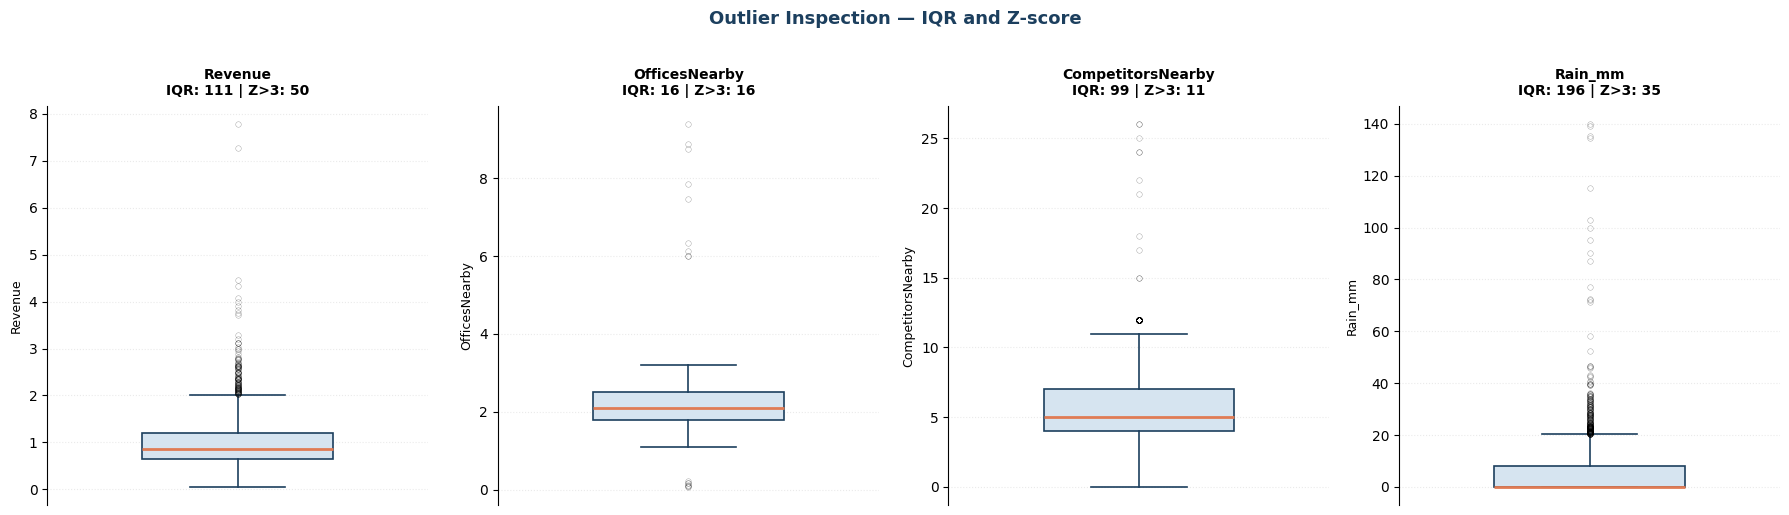

In [29]:
# Section 2.6 - Outlier inspection: IQR and z-score (Figure 6 in report)
from scipy import stats as scipy_stats

cols_to_check = ['Revenue', 'OfficesNearby', 'CompetitorsNearby', 'Rain_mm']

fig, axes = plt.subplots(1, 4, figsize=(18, 5), facecolor='white')

print("=== Outlier Summary: IQR + Z-score ===\n")

for ax, col in zip(axes, cols_to_check):
    data = train_df[col].dropna()

    # IQR method
    q1, q3  = data.quantile(0.25), data.quantile(0.75)
    iqr     = q3 - q1
    lower   = q1 - 1.5 * iqr
    upper   = q3 + 1.5 * iqr
    iqr_out = ((data < lower) | (data > upper)).sum()

    # Z-score method (flag |z| > 3)
    z_scores = np.abs(scipy_stats.zscore(data))
    z_out    = (z_scores > 3).sum()

    bp = ax.boxplot(data, patch_artist=True, vert=True, widths=0.5,
                    boxprops    =dict(facecolor='#D6E4F0', color='#1C3F5E', linewidth=1.2),
                    medianprops =dict(color='#E07B54', linewidth=2),
                    whiskerprops=dict(color='#1C3F5E', linewidth=1.2),
                    capprops    =dict(color='#1C3F5E', linewidth=1.2),
                    flierprops  =dict(marker='o', color='#4A7FB5',
                                      alpha=0.4, markersize=4,
                                      markeredgewidth=0.3))

    ax.set_title(f'{col}\nIQR: {iqr_out} | Z>3: {z_out}',
                 fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel(col, fontsize=9)
    ax.set_xticks([])
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)

    print(f"  {col}")
    print(f"    IQR fence  : [{lower:.4f}, {upper:.4f}]")
    print(f"    IQR outliers: {iqr_out} ({iqr_out/len(data)*100:.2f}%)")
    print(f"    Z>3 outliers: {z_out} ({z_out/len(data)*100:.2f}%)")
    print(f"    Min: {data.min():.4f}  Max: {data.max():.4f}\n")

fig.suptitle('Outlier Inspection — IQR and Z-score',
             fontsize=13, fontweight='bold', y=1.02, color='#1C3F5E')
plt.tight_layout()
plt.savefig('outlier_inspection.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

**Section 2.6 - Cross-check:** Are high-Revenue outliers tied to specific outlets or dates?

If extreme Revenue values all come from one or two outlets, they likely reflect a genuinely high-performing outlet rather than a data error. If they cluster on specific dates, it may indicate a special event or data collection anomaly. This cross-check tells us whether outliers are structural (outlet-specific) or incidental (random errors).


In [30]:
q1   = train_df['Revenue'].quantile(0.25)
q3   = train_df['Revenue'].quantile(0.75)
iqr  = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

high_outliers = train_df[train_df['Revenue'] > upper_fence].copy()
low_outliers  = train_df[train_df['Revenue'] < lower_fence].copy()

print(f"=== Extreme Revenue Rows ===")
print(f"  Upper fence : {upper_fence:.4f}")
print(f"  Lower fence : {lower_fence:.4f}")
print(f"  High outliers: {len(high_outliers)} rows")
print(f"  Low outliers : {len(low_outliers)} rows\n")

# which outlets appear most in high outliers
print("  Top outlets in HIGH Revenue outliers:")
print(high_outliers['OutletID'].value_counts().head(10).to_string())

print("\n  Top outlets in LOW Revenue outliers:")
print(low_outliers['OutletID'].value_counts().head(10).to_string())

# do outliers cluster on specific dates/months?
print("\n  High outliers by Month:")
print(high_outliers['Month'].value_counts().sort_index().to_string())

print("\n  Low outliers by Month:")
print(low_outliers['Month'].value_counts().sort_index().to_string())

# show the actual extreme rows
print("\n  Top 10 highest Revenue rows:")
print(train_df.nlargest(10, 'Revenue')[
    ['OutletID', 'Date', 'Month', 'Weekday',
     'Downtown', 'Mall', 'Revenue']].to_string(index=False))

print("\n  Top 10 lowest Revenue rows:")
print(train_df.nsmallest(10, 'Revenue')[
    ['OutletID', 'Date', 'Month', 'Weekday',
     'Downtown', 'Mall', 'Revenue']].to_string(index=False))

=== Extreme Revenue Rows ===
  Upper fence : 2.0199
  Lower fence : -0.1675
  High outliers: 111 rows
  Low outliers : 0 rows

  Top outlets in HIGH Revenue outliers:
OutletID
11    27
44    21
65    17
14     8
89     7
32     6
98     5
90     5
22     2
74     1

  Top outlets in LOW Revenue outliers:
Series([], )

  High outliers by Month:
Month
4    11
5    28
6    23
7    16
8    19
9    14

  Low outliers by Month:
Series([], )

  Top 10 highest Revenue rows:
 OutletID       Date  Month  Weekday  Downtown  Mall  Revenue
       90 2025-08-04      8        1         1     1 7.775264
       37 2025-05-15      5        1         0     1 7.282862
       44 2025-07-26      7        0         1     1 4.466756
       11 2025-07-28      7        1         1     1 4.329634
       57 2025-08-27      8        1         0     1 4.079482
       11 2025-07-04      7        1         1     1 4.000246
      105 2025-05-05      5        1         1     0 3.911953
       11 2025-09-19      9      

**Section 2.6 - Outlier documentation:** Summary for report. Outliers confirmed by assignment brief; no rows removed.

In [31]:
# Section 2.6 - Outlier documentation summary (referenced in report Section 2.6)
print("=== Outlier Documentation Summary (for report) ===\n")

outlier_summary = {
    'Revenue'          : train_df['Revenue'],
    'OfficesNearby'    : train_df['OfficesNearby'].dropna(),
    'CompetitorsNearby': train_df['CompetitorsNearby'].dropna(),
    'Rain_mm'          : train_df['Rain_mm'].dropna(),
}

for col, data in outlier_summary.items():
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr    = q3 - q1
    n_out  = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    pct    = n_out / len(data) * 100
    print(f"  {col:<22} {n_out:>4} outliers ({pct:.2f}%)"
          f"  |  max = {data.max():.4f}")

print("""
  Notes for modelling stage:
  - Outliers confirmed by assignment brief — do NOT drop blindly
  - Linear models (Ridge, Lasso): sensitive to outliers → consider
    robust scaling (RobustScaler) or log-transforming Revenue
  - Tree-based models (if covered): naturally robust to outliers
  - KNN: sensitive to scale → RobustScaler recommended
  - Revisit outlier treatment during cross-validation by comparing
    model performance with and without log(Revenue) as target
""")

=== Outlier Documentation Summary (for report) ===

  Revenue                 111 outliers (3.21%)  |  max = 7.7753
  OfficesNearby            16 outliers (0.47%)  |  max = 9.3822
  CompetitorsNearby        99 outliers (2.90%)  |  max = 26.0000
  Rain_mm                 196 outliers (5.83%)  |  max = 139.7610

  Notes for modelling stage:
  - Outliers confirmed by assignment brief — do NOT drop blindly
  - Linear models (Ridge, Lasso): sensitive to outliers → consider
    robust scaling (RobustScaler) or log-transforming Revenue
  - Tree-based models (if covered): naturally robust to outliers
  - KNN: sensitive to scale → RobustScaler recommended
  - Revisit outlier treatment during cross-validation by comparing
    model performance with and without log(Revenue) as target



## ---- Section 2.7: Relationships with Revenue ----

Pearson correlations, scatter plots, box plots by binary feature, LagHigh leakage check, and Month linearity check. Results correspond to Figures 4, 7, and 8 in the report.

**Section 2.7 - Pearson correlations:** Numeric features vs Revenue.

In [32]:
numeric_features = ['OfficesNearby', 'CompetitorsNearby',
                    'Rain_mm', 'Month']

print("=== Pearson Correlation with Revenue ===\n")
correlations = (train_df[numeric_features + ['Revenue']]
                .corr()['Revenue']
                .drop('Revenue')
                .sort_values(key=abs, ascending=False))

for feat, corr in correlations.items():
    bar   = '█' * int(abs(corr) * 40)
    direc = '+' if corr >= 0 else '-'
    print(f"  {feat:<22} {corr:>7.4f}  {direc} {bar}")

=== Pearson Correlation with Revenue ===

  CompetitorsNearby      -0.4383  - █████████████████
  OfficesNearby           0.2071  + ████████
  Month                  -0.0729  - ██
  Rain_mm                -0.0329  - █


**Section 2.7 - Scatter plots:** OfficesNearby, CompetitorsNearby, and Rain_mm vs Revenue.

Scatter plots reveal whether the feature-Revenue relationship is linear, curved, or negligible. For Rain_mm we look for a threshold effect beyond which Revenue drops.

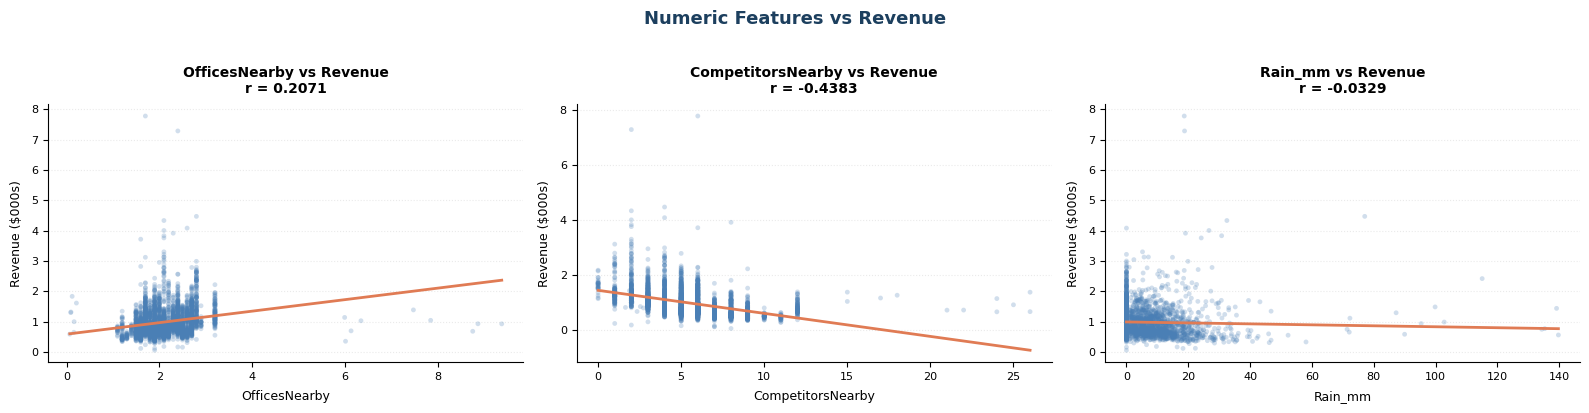

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

scatter_cols = ['OfficesNearby', 'CompetitorsNearby', 'Rain_mm']
bar_color    = '#4A7FB5'
line_color   = '#E07B54'

for ax, col in zip(axes, scatter_cols):
    subset = train_df[[col, 'Revenue']].dropna()
    x = subset[col].values
    y = subset['Revenue'].values

    ax.scatter(x, y, color=bar_color, alpha=0.25,
               s=12, edgecolors='none')

    # trend line
    z    = np.polyfit(x, y, 1)
    p    = np.poly1d(z)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, p(xline), color=line_color, linewidth=2)

    corr = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'{col} vs Revenue\nr = {corr:.4f}',
                 fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel(col, fontsize=9, labelpad=6)
    ax.set_ylabel('Revenue ($000s)', fontsize=9, labelpad=6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8)

fig.suptitle('Numeric Features vs Revenue',
             fontsize=13, fontweight='bold', y=1.02, color='#1C3F5E')
plt.tight_layout()
plt.savefig('scatter_numeric_revenue.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

**Section 2.7 - Box plots:** Revenue distribution by binary feature (Figure 4 in report).

Box plots show the full Revenue distribution for each class of a binary feature — not just the mean. This is richer than a bar chart because we can see whether the difference is driven by the median shifting, the spread changing, or extreme values appearing in one class. It helps us judge whether a feature genuinely separates Revenue distributions or just creates a small mean shift.

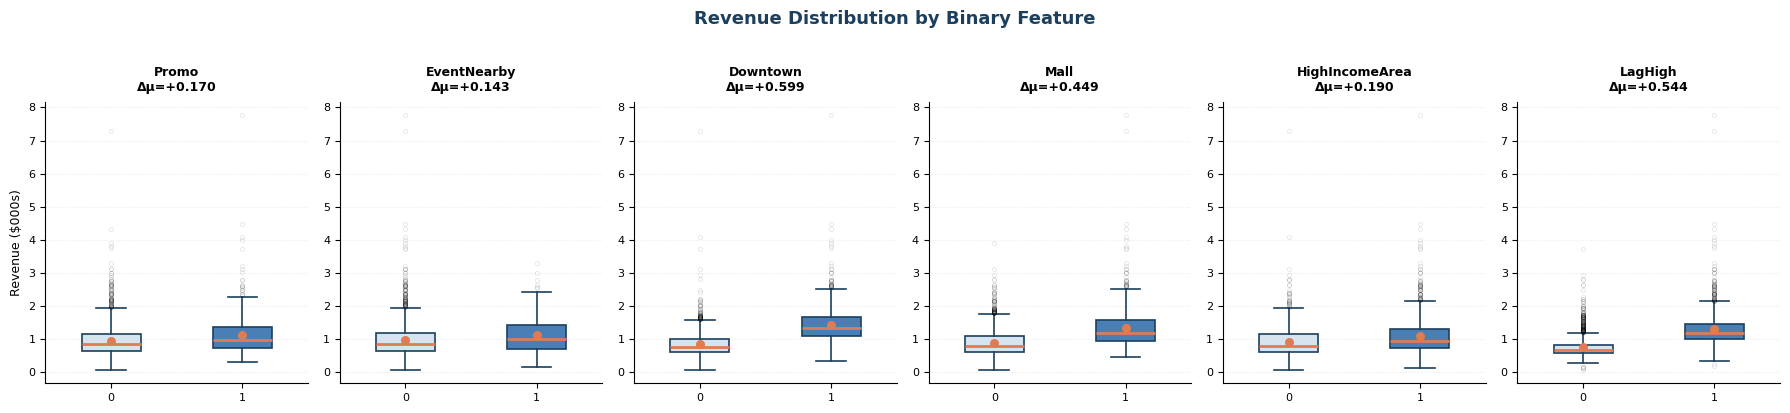

In [34]:
binary_features = ['Promo', 'EventNearby', 'Downtown',
                   'Mall', 'HighIncomeArea', 'LagHigh']

fig, axes = plt.subplots(1, len(binary_features),
                         figsize=(18, 4), facecolor='white')

colors = ['#D6E4F0', '#4A7FB5']

for ax, col in zip(axes, binary_features):
    groups = [
        train_df[train_df[col] == 0]['Revenue'].dropna(),
        train_df[train_df[col] == 1]['Revenue'].dropna()
    ]

    bp = ax.boxplot(groups, patch_artist=True, widths=0.45,
                    boxprops    =dict(linewidth=1.2),
                    medianprops =dict(color='#E07B54', linewidth=2),
                    whiskerprops=dict(color='#1C3F5E', linewidth=1.2),
                    capprops    =dict(color='#1C3F5E', linewidth=1.2),
                    flierprops  =dict(marker='o', alpha=0.2,
                                      markersize=3, markeredgewidth=0.3))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('#1C3F5E')

    means = [g.mean() for g in groups]
    ax.scatter([1, 2], means, color='#E07B54', zorder=5, s=30)

    diff = means[1] - means[0]
    ax.set_title(f'{col}\nΔμ={diff:+.3f}',
                 fontsize=9, fontweight='bold', pad=8)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['0', '1'], fontsize=8)
    ax.set_ylabel('Revenue ($000s)' if col == binary_features[0] else '',
                  fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8)

fig.suptitle('Revenue Distribution by Binary Feature',
             fontsize=13, fontweight='bold', y=1.02, color='#1C3F5E')
plt.tight_layout()
plt.savefig('boxplot_binary_revenue.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

**Section 2.7 - LagHigh leakage and predictiveness check:** LagHigh encodes whether the previous month's mean Revenue exceeded the global median. Must confirm it is not leaked current-period information.

In [35]:
from scipy import stats as scipy_stats

print("=== LagHigh Leakage and Predictiveness Check ===\n")

# mean revenue by LagHigh class
lag0 = train_df[train_df['LagHigh'] == 0]['Revenue'].dropna()
lag1 = train_df[train_df['LagHigh'] == 1]['Revenue'].dropna()

t_stat, p_val = scipy_stats.ttest_ind(lag0, lag1)

print(f"  Mean Revenue (LagHigh=0) : {lag0.mean():.4f}")
print(f"  Mean Revenue (LagHigh=1) : {lag1.mean():.4f}")
print(f"  Difference               : {lag1.mean() - lag0.mean():.4f}")
print(f"  T-statistic              : {t_stat:.4f}")
print(f"  P-value                  : {p_val:.6f}")
print()

if p_val < 0.05:
    print("  LagHigh is statistically significant — genuinely predictive.")
else:
    print("  LagHigh is NOT statistically significant.")

=== LagHigh Leakage and Predictiveness Check ===

  Mean Revenue (LagHigh=0) : 0.7543
  Mean Revenue (LagHigh=1) : 1.2982
  Difference               : 0.5439
  T-statistic              : -38.7043
  P-value                  : 0.000000

  LagHigh is statistically significant — genuinely predictive.


**Section 2.7 - Month linearity check:** Compare linear vs quadratic fit to determine if Month needs polynomial or cyclic encoding.



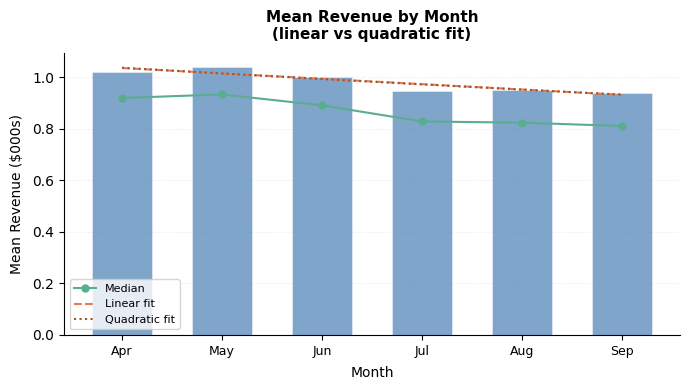

  Linear correlation (Month vs Revenue): -0.0729
  If linear and quadratic fits look similar → Month is monotonic
  If quadratic fits much better → consider Month^2 or categorical encoding


In [36]:
month_stats = (train_df.groupby('Month')['Revenue']
               .agg(['mean', 'median', 'std'])
               .reset_index())

fig, ax = plt.subplots(figsize=(7, 4), facecolor='white')

x = month_stats['Month'].values
y = month_stats['mean'].values

ax.bar(x, y, color='#4A7FB5', alpha=0.7,
       edgecolor='white', linewidth=0.4, width=0.6)
ax.plot(x, month_stats['median'].values, color='#5BAD8F',
        marker='o', markersize=5, linewidth=1.5, label='Median')

# linear fit
z1   = np.polyfit(x, y, 1)
p1   = np.poly1d(z1)
# quadratic fit
z2   = np.polyfit(x, y, 2)
p2   = np.poly1d(z2)

xline = np.linspace(x.min(), x.max(), 200)
ax.plot(xline, p1(xline), color='#E07B54',
        linewidth=1.5, linestyle='--', label='Linear fit')
ax.plot(xline, p2(xline), color='#A0522D',
        linewidth=1.5, linestyle=':', label='Quadratic fit')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks(x)
ax.set_xticklabels([month_labels[m-1] for m in x], fontsize=9)
ax.set_title('Mean Revenue by Month\n(linear vs quadratic fit)',
             fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Month', fontsize=10, labelpad=6)
ax.set_ylabel('Mean Revenue ($000s)', fontsize=10, labelpad=6)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('month_revenue_fit.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# correlation check
lin_corr = train_df['Month'].corr(train_df['Revenue'])
print(f"  Linear correlation (Month vs Revenue): {lin_corr:.4f}")
print("  If linear and quadratic fits look similar → Month is monotonic")
print("  If quadratic fits much better → consider Month^2 or categorical encoding")

## ---- Section 2.8: Leakage Checks ----

Verify LagHigh, Date/Month, test file alignment, and feature independence from Revenue.

In [37]:
print("=== LagHigh Leakage Check ===\n")

# Check correlation of LagHigh with current month Revenue
current_corr = train_df['LagHigh'].corr(train_df['Revenue'])
print(f"  Correlation LagHigh vs current Revenue  : {current_corr:.4f}")

# Check if LagHigh value is consistent within outlet-month
# (it should be the same for all days of the same outlet in same month)
laghigh_consistency = (train_df.groupby(['OutletID', 'Month'])['LagHigh']
                       .nunique())
inconsistent = (laghigh_consistency > 1).sum()
print(f"  Outlet-Month groups where LagHigh varies: {inconsistent}")

if inconsistent == 0:
    print("  LagHigh is constant within each OutletID-Month group.")
    print("  This confirms it is a monthly-level lag, not a daily one.")
else:
    print("  WARNING: LagHigh varies within some Outlet-Month groups.")
    print("  Investigate — may indicate leakage.")

print("""
  Leakage verdict:
  - LagHigh encodes PREVIOUS month performance, not current
  - It is constant within each outlet-month (monthly granularity)
  - Correlation with Revenue is strong but legitimate (persistence effect)
  - SAFE to use as a feature — no leakage detected
""")

=== LagHigh Leakage Check ===

  Correlation LagHigh vs current Revenue  : 0.5500
  Outlet-Month groups where LagHigh varies: 0
  LagHigh is constant within each OutletID-Month group.
  This confirms it is a monthly-level lag, not a daily one.

  Leakage verdict:
  - LagHigh encodes PREVIOUS month performance, not current
  - It is constant within each outlet-month (monthly granularity)
  - Correlation with Revenue is strong but legitimate (persistence effect)
  - SAFE to use as a feature — no leakage detected



**Section 2.8 - Check:** Date and Month must not encode future Revenue information.

In [38]:
print("=== Date / Month Leakage Check ===\n")

# Confirm Month is simply extracted from Date — not derived from Revenue
train_df['Date'] = pd.to_datetime(train_df['Date'])
train_df['Month_from_date'] = train_df['Date'].dt.month

mismatches = (train_df['Month'] != train_df['Month_from_date']).sum()
print(f"  Rows where Month != month extracted from Date: {mismatches}")

if mismatches == 0:
    print("  Month is consistent with Date — purely calendar-derived.")
    print("  No Revenue information encoded. SAFE.")
else:
    print("  WARNING: Month does not match Date in some rows — investigate.")

# Confirm Date itself has no direct Revenue encoding
date_corr = train_df['Date'].map(pd.Timestamp.toordinal).corr(train_df['Revenue'])
print(f"\n  Correlation of Date (ordinal) with Revenue: {date_corr:.4f}")
print("  Low/moderate correlation expected — Date is a time proxy, not a Revenue encoder.")

# clean up helper column
train_df.drop(columns=['Month_from_date'], inplace=True)

=== Date / Month Leakage Check ===

  Rows where Month != month extracted from Date: 0
  Month is consistent with Date — purely calendar-derived.
  No Revenue information encoded. SAFE.

  Correlation of Date (ordinal) with Revenue: -0.0754
  Low/moderate correlation expected — Date is a time proxy, not a Revenue encoder.


**Section 2.8 - Check:** Test_noLabel.csv must not contain Revenue column. All feature columns must be present.



In [39]:
test_df = pd.read_csv('Test_noLabel.csv')

print("=== Train vs Test Column Alignment ===\n")

train_cols = set(train_df.columns)
test_cols  = set(test_df.columns)

print(f"  Training columns : {sorted(train_cols)}")
print(f"  Test columns     : {sorted(test_cols)}")

# Check Revenue is absent from test
if 'Revenue' in test_cols:
    print("\n  WARNING: Revenue column found in test file — LEAKAGE RISK.")
    print("  Drop Revenue from test before predicting.")
else:
    print("\n  Revenue column correctly absent from test file. SAFE.")

# Check for any missing columns in test
missing_in_test = train_cols - test_cols - {'Revenue'}
extra_in_test   = test_cols - train_cols

if missing_in_test:
    print(f"\n  Columns in train but missing from test: {missing_in_test}")
else:
    print("  All training feature columns present in test. SAFE.")

if extra_in_test:
    print(f"\n  Extra columns in test not in train: {extra_in_test}")
else:
    print("  No unexpected extra columns in test.")

=== Train vs Test Column Alignment ===

  Training columns : ['CompetitorsNearby', 'Date', 'Downtown', 'EventNearby', 'HighIncomeArea', 'LagHigh', 'Mall', 'Month', 'OfficesNearby', 'OutletID', 'Promo', 'Rain_mm', 'Revenue', 'Weekday']
  Test columns     : ['CompetitorsNearby', 'Date', 'Downtown', 'EventNearby', 'HighIncomeArea', 'LagHigh', 'Mall', 'Month', 'OfficesNearby', 'OutletID', 'Promo', 'Rain_mm', 'Weekday']

  Revenue column correctly absent from test file. SAFE.
  All training feature columns present in test. SAFE.
  No unexpected extra columns in test.


**Section 2.8 - Check:** Confirm no feature has |r| > 0.95 with Revenue (would indicate derivation from target).

In [40]:
# Section 2.8 - Deterministic function check: flag any feature with |r| > 0.95 vs Revenue
print("=== Deterministic Function of Revenue Check ===\n")

feature_cols = [c for c in train_df.columns
                if c not in ['Revenue', 'OutletID', 'Date']]

correlations = {}
for col in feature_cols:
    try:
        r = train_df[col].corr(train_df['Revenue'])
        correlations[col] = r
    except:
        correlations[col] = np.nan

corr_series = (pd.Series(correlations)
               .abs()
               .sort_values(ascending=False))

print("  Feature correlations with Revenue (|r|, sorted):")
for feat, val in corr_series.items():
    flag = " ← INVESTIGATE" if val > 0.95 else ""
    print(f"    {feat:<22} {val:.4f}{flag}")

suspicious = corr_series[corr_series > 0.95]
print()
if len(suspicious) > 0:
    print(f"  WARNING: {len(suspicious)} feature(s) have |r| > 0.95 with Revenue.")
    print("  These may be derived from Revenue — investigate immediately.")
else:
    print("  No feature has |r| > 0.95 with Revenue.")
    print("  No deterministic leakage detected. SAFE.")

=== Deterministic Function of Revenue Check ===

  Feature correlations with Revenue (|r|, sorted):
    LagHigh                0.5500
    Downtown               0.5236
    CompetitorsNearby      0.4383
    Mall                   0.3765
    OfficesNearby          0.2071
    Weekday                0.1912
    HighIncomeArea         0.1902
    Promo                  0.1343
    EventNearby            0.0850
    Month                  0.0729
    Rain_mm                0.0329

  No feature has |r| > 0.95 with Revenue.
  No deterministic leakage detected. SAFE.


## ---- Section 2.8: Feature-Feature Relationships ----
Correlation heatmap, multicollinearity flags, and interaction effects. Results correspond to Figures 9 and 10 in the report.

**Section 2.8 - Correlation matrix:** All features including Revenue (Figure 9 in report).



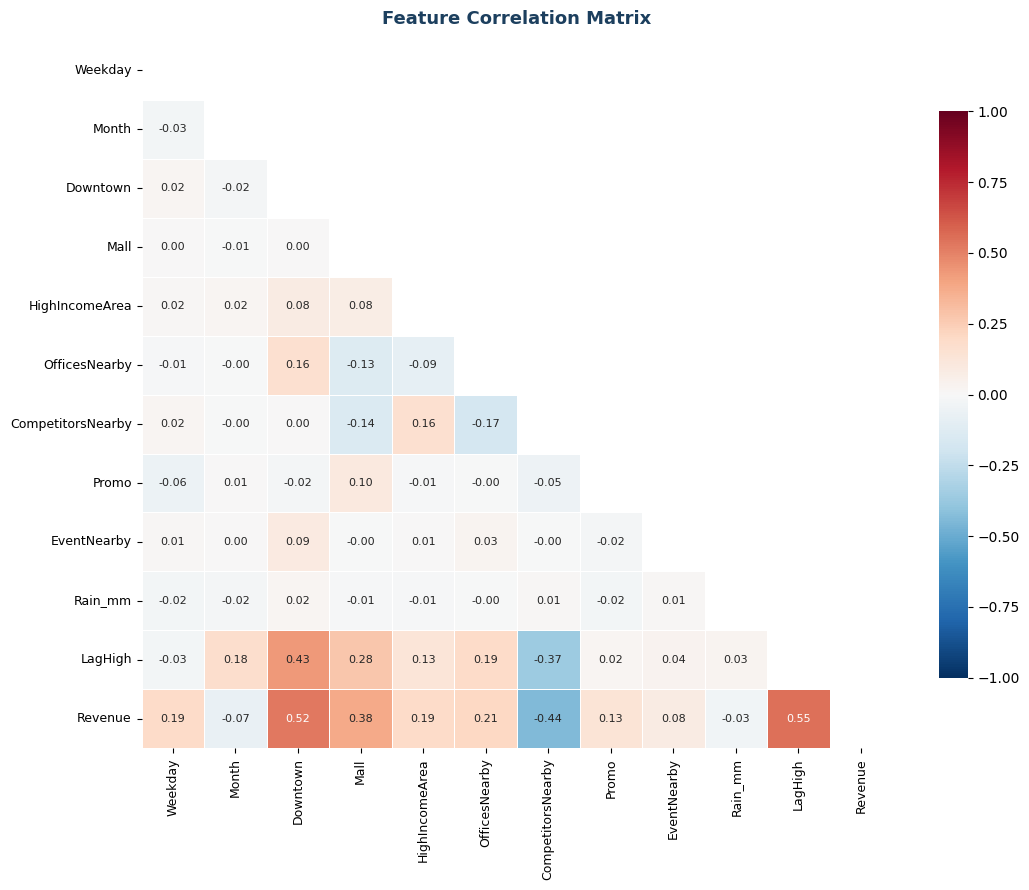

In [41]:
import seaborn as sns
feature_cols = ['Weekday', 'Month', 'Downtown', 'Mall', 'HighIncomeArea',
                'OfficesNearby', 'CompetitorsNearby', 'Promo',
                'EventNearby', 'Rain_mm', 'LagHigh', 'Revenue']

corr_matrix = train_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9), facecolor='white')

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'shrink': 0.8}
)

ax.set_title('Feature Correlation Matrix',
             fontsize=13, fontweight='bold', pad=12, color='#1C3F5E')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

**Section 2.8 - Multicollinearity check:** Flag pairs with |r| > 0.8. None found in this dataset.

In [42]:
# Section 2.8 - Flag highly correlated feature pairs (|r| > 0.8 threshold)

print("=== Highly Correlated Feature Pairs (|r| > 0.8) ===\n")

pairs_found = False
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8 and cols[i] != 'Revenue' and cols[j] != 'Revenue':
            print(f"  {cols[i]:<22} vs {cols[j]:<22} r = {r:.4f}  ← FLAG")
            pairs_found = True

if not pairs_found:
    print("  No feature pairs exceed |r| > 0.8 threshold.")
    print("  Multicollinearity is not a major concern in this dataset.")

print("""
  Note: Even without pairs above 0.8, moderate correlations (0.4–0.8)
  between Downtown, OfficesNearby, and Mall are worth monitoring.
  Ridge/Lasso regularisation handles this automatically.
""")

=== Highly Correlated Feature Pairs (|r| > 0.8) ===

  No feature pairs exceed |r| > 0.8 threshold.
  Multicollinearity is not a major concern in this dataset.

  Note: Even without pairs above 0.8, moderate correlations (0.4–0.8)
  between Downtown, OfficesNearby, and Mall are worth monitoring.
  Ridge/Lasso regularisation handles this automatically.



**Section 2.8 - Interaction check:** Promo x Weekday and EventNearby x Weekday (Figure 10 in report). Non-parallel lines indicate a genuine interaction effect.

=== Promo × Weekday ===
  Promo=0, Weekend: 0.7959 | Promo=0, Weekday: 1.0084
  Promo=1, Weekend: 0.9579 | Promo=1, Weekday: 1.2019
  Effect of Promo on Weekend: +0.1620
  Effect of Promo on Weekday: +0.1935
  No strong interaction — lines are roughly parallel

=== EventNearby × Weekday ===
  EventNearby=0, Weekend: 0.8298 | EventNearby=0, Weekday: 1.0241
  EventNearby=1, Weekend: 0.8481 | EventNearby=1, Weekday: 1.2073
  Effect of EventNearby on Weekend: +0.0184
  Effect of EventNearby on Weekday: +0.1832
  Interaction likely present — lines are non-parallel



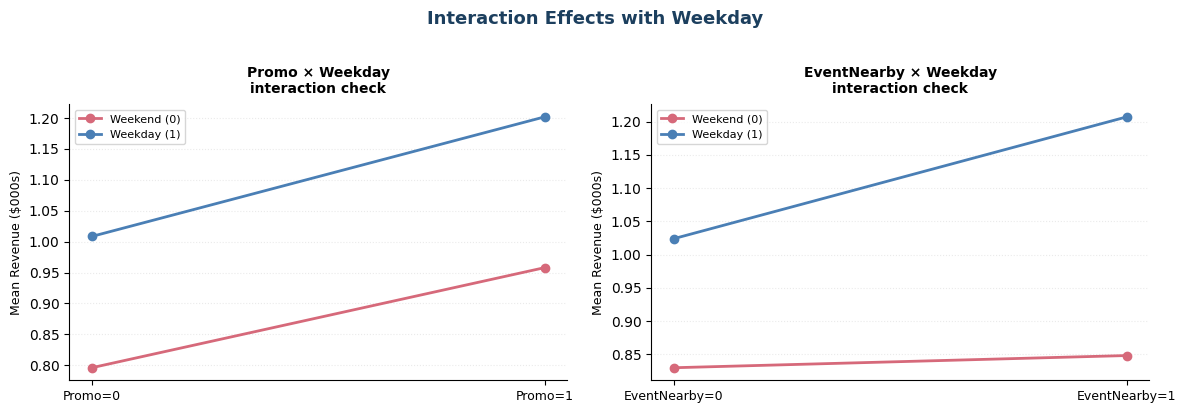

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='white')

interactions = [('Promo', 'Weekday'), ('EventNearby', 'Weekday')]
colors = {'Weekend (0)': '#D6E4F0', 'Weekday (1)': '#4A7FB5'}

for ax, (feat, moderator) in zip(axes, interactions):
    groups = {}
    for mod_val, mod_label in [(0, 'Weekend (0)'), (1, 'Weekday (1)')]:
        for feat_val in [0, 1]:
            subset = train_df[
                (train_df[moderator] == mod_val) &
                (train_df[feat] == feat_val)
            ]['Revenue']
            groups[(mod_label, feat_val)] = subset.mean()

    x       = np.array([0, 1])
    weekend = [groups[('Weekend (0)', 0)], groups[('Weekend (0)', 1)]]
    weekday = [groups[('Weekday (1)', 0)], groups[('Weekday (1)', 1)]]

    ax.plot(x, weekend, marker='o', color='#D6697A',
            linewidth=2, markersize=6, label='Weekend (0)')
    ax.plot(x, weekday, marker='o', color='#4A7FB5',
            linewidth=2, markersize=6, label='Weekday (1)')

    # if lines are NOT parallel, interaction exists
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'{feat}=0', f'{feat}=1'], fontsize=9)
    ax.set_title(f'{feat} × {moderator}\ninteraction check',
                 fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel('Mean Revenue ($000s)', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)

    # print values
    print(f"=== {feat} × {moderator} ===")
    print(f"  {feat}=0, Weekend: {weekend[0]:.4f} | "
          f"{feat}=0, Weekday: {weekday[0]:.4f}")
    print(f"  {feat}=1, Weekend: {weekend[1]:.4f} | "
          f"{feat}=1, Weekday: {weekday[1]:.4f}")
    diff_weekend = weekend[1] - weekend[0]
    diff_weekday = weekday[1] - weekday[0]
    print(f"  Effect of {feat} on Weekend: {diff_weekend:+.4f}")
    print(f"  Effect of {feat} on Weekday: {diff_weekday:+.4f}")
    if abs(diff_weekday - diff_weekend) > 0.05:
        print(f"  Interaction likely present — lines are non-parallel")
    else:
        print(f"  No strong interaction — lines are roughly parallel")
    print()

fig.suptitle('Interaction Effects with Weekday',
             fontsize=13, fontweight='bold', y=1.02, color='#1C3F5E')
plt.tight_layout()
plt.savefig('interaction_plots.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## ---- Section 2.9: Outlet-Level Structure ----

Panel balance, static location features, mean Revenue per outlet, and variance decomposition. This is the most important EDA finding: outlet identity alone explains R-squared = 0.7231 of total Revenue variance. Results correspond to Figure 11 in the report.

In [44]:
print("=== Observations per OutletID ===\n")

obs_per_outlet = train_df.groupby('OutletID').size()
print(f"  Total outlets       : {obs_per_outlet.count()}")
print(f"  Min observations    : {obs_per_outlet.min()}")
print(f"  Max observations    : {obs_per_outlet.max()}")
print(f"  Mean observations   : {obs_per_outlet.mean():.1f}")
print(f"  Std observations    : {obs_per_outlet.std():.1f}")
print(f"  Outlets with < 20   : {(obs_per_outlet < 20).sum()}")
print(f"  Outlets with >= 20  : {(obs_per_outlet >= 20).sum()}")

print("\n  Distribution of observations per outlet:")
print(obs_per_outlet.describe().round(2).to_string())

=== Observations per OutletID ===

  Total outlets       : 120
  Min observations    : 13
  Max observations    : 41
  Mean observations   : 28.8
  Std observations    : 5.6
  Outlets with < 20   : 5
  Outlets with >= 20  : 115

  Distribution of observations per outlet:
count    120.00
mean      28.80
std        5.56
min       13.00
25%       24.00
50%       29.00
75%       33.00
max       41.00


**Section 2.9 - Check:** Confirm Downtown, Mall, HighIncomeArea are static within each outlet.

In [45]:
print("=== Location Feature Constancy within OutletID ===\n")

for col in ['Downtown', 'Mall', 'HighIncomeArea']:
    nunique = train_df.groupby('OutletID')[col].nunique()
    varies  = (nunique > 1).sum()
    static  = (nunique == 1).sum()
    print(f"  {col}")
    print(f"    Constant across all dates : {static} outlets")
    print(f"    Varies across dates       : {varies} outlets")
    if varies == 0:
        print(f"    → Fully static — outlet-level attribute confirmed")
    else:
        print(f"    → WARNING: varies within outlet — investigate")
    print()

=== Location Feature Constancy within OutletID ===

  Downtown
    Constant across all dates : 120 outlets
    Varies across dates       : 0 outlets
    → Fully static — outlet-level attribute confirmed

  Mall
    Constant across all dates : 120 outlets
    Varies across dates       : 0 outlets
    → Fully static — outlet-level attribute confirmed

  HighIncomeArea
    Constant across all dates : 120 outlets
    Varies across dates       : 0 outlets
    → Fully static — outlet-level attribute confirmed



**Section 2.9 - Plot:** Mean Revenue per outlet sorted ascending (Figure 11 in report). Wide spread motivates outlet-level feature engineering.

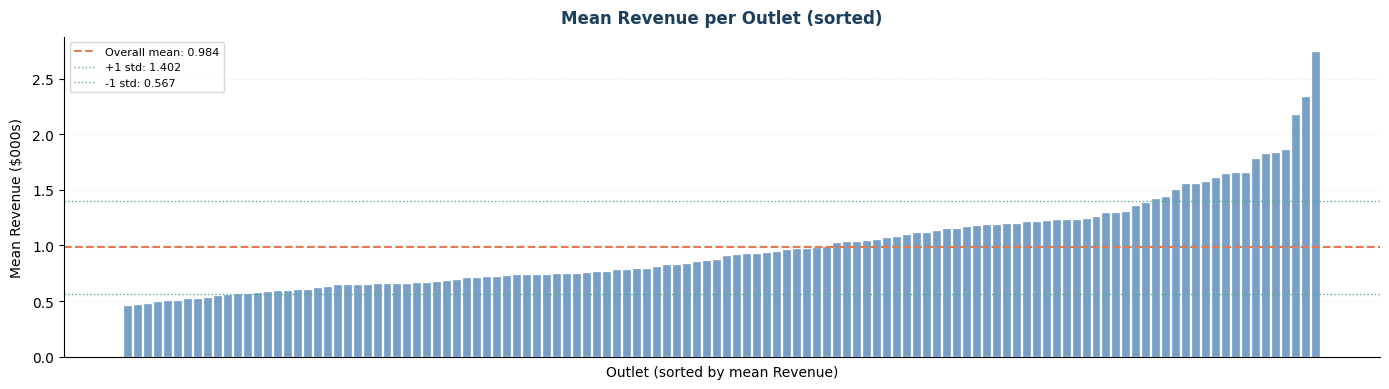

  Outlet mean Revenue std : 0.4171
  Ratio std/mean          : 0.4237
  High ratio → large outlet-level variance → outlet features will help


In [46]:
# Section 2.9 - Mean Revenue per outlet (Figure 11 in report)

outlet_means = (train_df.groupby('OutletID')['Revenue']
                .mean()
                .sort_values())

fig, ax = plt.subplots(figsize=(14, 4), facecolor='white')

ax.bar(range(len(outlet_means)), outlet_means.values,
       color='#4A7FB5', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axhline(outlet_means.mean(), color='#E07B54',
           linewidth=1.5, linestyle='--',
           label=f'Overall mean: {outlet_means.mean():.3f}')
ax.axhline(outlet_means.mean() + outlet_means.std(),
           color='#5BAD8F', linewidth=1, linestyle=':',
           label=f'+1 std: {outlet_means.mean()+outlet_means.std():.3f}')
ax.axhline(outlet_means.mean() - outlet_means.std(),
           color='#5BAD8F', linewidth=1, linestyle=':',
           label=f'-1 std: {outlet_means.mean()-outlet_means.std():.3f}')

ax.set_title('Mean Revenue per Outlet (sorted)',
             fontsize=12, fontweight='bold', pad=10, color='#1C3F5E')
ax.set_xlabel('Outlet (sorted by mean Revenue)', fontsize=10, labelpad=6)
ax.set_ylabel('Mean Revenue ($000s)', fontsize=10, labelpad=6)
ax.set_xticks([])
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('outlet_mean_revenue.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"  Outlet mean Revenue std : {outlet_means.std():.4f}")
print(f"  Ratio std/mean          : {outlet_means.std()/outlet_means.mean():.4f}")
print("  High ratio → large outlet-level variance → outlet features will help")

**Section 2.9 - Variance decomposition:** Quantify how much Revenue variance is explained by outlet identity alone.

In [47]:
# Section 2.9 - Variance decomposition: R-squared from outlet identity alone
# compute how much variance is explained by outlet identity alone
grand_mean    = train_df['Revenue'].mean()
outlet_means_ = train_df.groupby('OutletID')['Revenue'].transform('mean')

ss_total   = ((train_df['Revenue'] - grand_mean) ** 2).sum()
ss_between = ((outlet_means_ - grand_mean) ** 2).sum()
ss_within  = ((train_df['Revenue'] - outlet_means_) ** 2).sum()

r2_outlet = ss_between / ss_total

print("=== Outlet-Level Variance Decomposition ===\n")
print(f"  SS Total   : {ss_total:.4f}")
print(f"  SS Between outlets (explained by outlet identity): {ss_between:.4f}")
print(f"  SS Within  (residual within outlets)             : {ss_within:.4f}")
print(f"  R² from outlet identity alone                    : {r2_outlet:.4f}")
print()
if r2_outlet > 0.3:
    print("  Outlet identity explains > 30% of Revenue variance.")
    print("  Strongly recommend engineering outlet-level mean Revenue")
    print("  as a feature — this alone could substantially reduce MSE.")
else:
    print("  Outlet identity explains moderate variance.")
    print("  Outlet-level features worth including but not dominant.")

=== Outlet-Level Variance Decomposition ===

  SS Total   : 824.6147
  SS Between outlets (explained by outlet identity): 596.2643
  SS Within  (residual within outlets)             : 228.3504
  R² from outlet identity alone                    : 0.7231

  Outlet identity explains > 30% of Revenue variance.
  Strongly recommend engineering outlet-level mean Revenue
  as a feature — this alone could substantially reduce MSE.


## ---- Section 2.10: Train vs Test Alignment ----

Compare feature distributions, date ranges, and OutletID overlap between training and test sets.

**Section 2.10 - Distribution comparison:** If test data comes from a different time period or has shifted feature distributions, model performance can degrade.

In [48]:
# Section 2.10 - Feature distribution comparison: train vs test
test_df = pd.read_csv('Test_noLabel.csv')
test_df['Date'] = pd.to_datetime(test_df['Date'])

compare_cols = ['Weekday', 'Month', 'Downtown', 'Mall', 'HighIncomeArea',
                'OfficesNearby', 'CompetitorsNearby', 'Promo',
                'EventNearby', 'Rain_mm', 'LagHigh']

print("=== Feature Distribution Comparison: Train vs Test ===\n")
print(f"  {'Feature':<22} {'Train Mean':>12} {'Test Mean':>12} "
      f"{'Train Std':>12} {'Test Std':>12}")
print("  " + "-" * 72)

for col in compare_cols:
    t_mean = train_df[col].mean()
    te_mean = test_df[col].mean()
    t_std  = train_df[col].std()
    te_std = test_df[col].std()
    flag   = " ←" if abs(t_mean - te_mean) > 0.1 * t_std else ""
    print(f"  {col:<22} {t_mean:>12.4f} {te_mean:>12.4f} "
          f"{t_std:>12.4f} {te_std:>12.4f}{flag}")

=== Feature Distribution Comparison: Train vs Test ===

  Feature                  Train Mean    Test Mean    Train Std     Test Std
  ------------------------------------------------------------------------
  Weekday                      0.7280       0.7361       0.4450       0.4410
  Month                        6.5020       6.4329       1.6849       1.7203
  Downtown                     0.2393       0.2326       0.4267       0.4228
  Mall                         0.2138       0.2326       0.4101       0.4228
  HighIncomeArea               0.4012       0.3792       0.4902       0.4855
  OfficesNearby                2.1234       2.0843       0.5345       0.4617
  CompetitorsNearby            5.4424       5.4179       2.5524       2.4159
  Promo                        0.1834       0.1829       0.3871       0.3868
  EventNearby                  0.0926       0.0995       0.2899       0.2996
  Rain_mm                      5.3091       4.7149      10.0583       8.0196
  LagHigh             

**Section 2.10 - Check:** Date range overlap between training and test sets.

In [49]:
# Section 2.10 - Date range check: does test period follow or overlap training?

print("\n=== Date Range Check ===\n")
print(f"  Train: {train_df['Date'].min().date()} → {train_df['Date'].max().date()}")
print(f"  Test : {test_df['Date'].min().date()} → {test_df['Date'].max().date()}")

overlap = train_df['Date'].isin(test_df['Date']).sum()
print(f"\n  Overlapping dates: {overlap}")

if overlap == 0:
    print("  No overlap — test period is distinct from training.")
    print("  Temporal ordering respected. No date-based leakage.")
elif test_df['Date'].max() > train_df['Date'].max():
    print("  Test period extends beyond training — genuine future prediction.")
else:
    print("  Test overlaps with training period — check for row-level leakage.")


=== Date Range Check ===

  Train: 2025-04-01 → 2025-09-27
  Test : 2025-04-01 → 2025-09-27

  Overlapping dates: 3435
  Test overlaps with training period — check for row-level leakage.


**Section 2.10 - Check:** OutletIDs in test must all appear in training, otherwise outlet-level features produce NaN.

In [50]:
# Section 2.10 - OutletID overlap: all test outlets must be seen in training

print("\n=== OutletID Overlap Check ===\n")

train_outlets = set(train_df['OutletID'].unique())
test_outlets  = set(test_df['OutletID'].unique())

unseen = test_outlets - train_outlets
seen   = test_outlets & train_outlets

print(f"  Outlets in training : {len(train_outlets)}")
print(f"  Outlets in test     : {len(test_outlets)}")
print(f"  Seen in both        : {len(seen)}")
print(f"  Unseen in test      : {len(unseen)}")

if len(unseen) > 0:
    print(f"\n  WARNING: {len(unseen)} test outlets never seen in training.")
    print(f"  Outlet IDs: {sorted(unseen)}")
    print("  Any outlet-level engineered feature will be NaN for these.")
    print("  Plan a fallback (e.g. global mean) for unseen outlets.")
else:
    print("\n  All test outlets appear in training. SAFE.")
    print("  Outlet-level engineered features will work for all test rows.")


=== OutletID Overlap Check ===

  Outlets in training : 120
  Outlets in test     : 120
  Seen in both        : 120
  Unseen in test      : 0

  All test outlets appear in training. SAFE.
  Outlet-level engineered features will work for all test rows.


In [51]:
# Section 2.10 - Distribution shift summary
print("""
=== Distribution Shift Summary (for report) ===

  Check the flagged columns (← ) from the distribution comparison above.
  For any column with meaningful mean shift between train and test:

  - If Month shifts: test period is in different months → model may
    extrapolate beyond observed month range
  - If Rain_mm shifts: test has different weather patterns → Rain
    features may behave differently
  - If Promo/EventNearby shift: different promotional calendar in
    test period → binary feature distributions change

  Implication for modelling:
  - Standardise features using training statistics only (fit scaler
    on train, transform both train and test)
  - Never fit the scaler on test data — this would leak test
    distribution information into our preprocessing
""")


=== Distribution Shift Summary (for report) ===

  Check the flagged columns (← ) from the distribution comparison above.
  For any column with meaningful mean shift between train and test:

  - If Month shifts: test period is in different months → model may
    extrapolate beyond observed month range
  - If Rain_mm shifts: test has different weather patterns → Rain
    features may behave differently
  - If Promo/EventNearby shift: different promotional calendar in
    test period → binary feature distributions change

  Implication for modelling:
  - Standardise features using training statistics only (fit scaler
    on train, transform both train and test)
  - Never fit the scaler on test data — this would leak test
    distribution information into our preprocessing



In [52]:
# Remove any helper columns created during EDA
cols_to_drop = ['outlet_mean', 'Revenue_demeaned', 'n_missing']
train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns], inplace=True)
test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns], inplace=True)

print("Train columns after cleanup:", train_df.columns.tolist())
print("Test columns after cleanup :", test_df.columns.tolist())

Train columns after cleanup: ['OutletID', 'Date', 'Weekday', 'Month', 'Downtown', 'Mall', 'HighIncomeArea', 'OfficesNearby', 'CompetitorsNearby', 'Promo', 'EventNearby', 'Rain_mm', 'LagHigh', 'Revenue']
Test columns after cleanup : ['OutletID', 'Date', 'Weekday', 'Month', 'Downtown', 'Mall', 'HighIncomeArea', 'OfficesNearby', 'CompetitorsNearby', 'Promo', 'EventNearby', 'Rain_mm', 'LagHigh']


# ============================================================
# SECTION 3: FEATURE ENGINEERING 
# ============================================================
Engineer new features based on EDA findings. All outlet-level features are computed from training data only to prevent leakage. See Table 3 in the report for the full justification of each engineered feature.

The final feature set contains 17 columns (7 numeric, 10 binary/indicator). Raw Rain_mm and OutletMedianRevenue are excluded from the feature set.

## ---- Section 3: Outlet-Level Features ----

**OutletMeanRevenue** and **OutletStdRevenue**: motivated by outlet identity explaining R-squared = 0.7231 of variance (Section 2.9). Computed from training data only to prevent leakage; test outlets are mapped via training-derived statistics.

In [53]:
# Section 3 - Outlet-level features: mean and std Revenue per outlet
# Compute outlet statistics from TRAINING data only
# Never touch test Revenue — it does not exist
outlet_mean_rev   = train_df.groupby('OutletID')['Revenue'].mean()
outlet_median_rev = train_df.groupby('OutletID')['Revenue'].median()
outlet_std_rev    = train_df.groupby('OutletID')['Revenue'].std()

# Map onto both train and test using OutletID
for df in [train_df, test_df]:
    df['OutletMeanRevenue']   = df['OutletID'].map(outlet_mean_rev)
    df['OutletMedianRevenue'] = df['OutletID'].map(outlet_median_rev)
    df['OutletStdRevenue']    = df['OutletID'].map(outlet_std_rev)

print("Outlet-level features added.")
print(train_df[['OutletID','OutletMeanRevenue',
                'OutletMedianRevenue','OutletStdRevenue']].head())

Outlet-level features added.
   OutletID  OutletMeanRevenue  OutletMedianRevenue  OutletStdRevenue
0         9           0.678507             0.669649          0.086534
1        65           2.170588             2.289662          0.397695
2        16           1.023817             0.988236          0.184866
3        88           0.554777             0.550599          0.101239
4       100           0.832555             0.825746          0.147263


## ---- Section 3: Rain Features ----

**RainToday** (binary wet/dry) and **Rain_log1p** (log-compressed amount): motivated by Rain_mm having 55.3% zero-inflation and skewness of 5.3372 (Section 2.6). Two separate features capture the two distinct behaviours: whether it rained at all, and how much it rained on rainy days.

In [54]:
for df in [train_df, test_df]:
    # Fill Rain_mm NaN with 0 before engineering
    # Justified by EDA: NaN means 'not recorded', 1860 genuine zeros exist
    # so treating unrecorded rain as dry is the most conservative assumption
    rain_filled = df['Rain_mm'].fillna(0)
    df['RainToday']  = (rain_filled > 0).astype(int)
    df['Rain_log1p'] = np.log1p(rain_filled)

print("Rain features added.")
print(f"  NaNs in RainToday  (train): {train_df['RainToday'].isnull().sum()}")
print(f"  NaNs in Rain_log1p (train): {train_df['Rain_log1p'].isnull().sum()}")
print(train_df[['Rain_mm', 'RainToday', 'Rain_log1p']].head(8))

Rain features added.
  NaNs in RainToday  (train): 0
  NaNs in Rain_log1p (train): 0
   Rain_mm  RainToday  Rain_log1p
0      0.0          0    0.000000
1      0.0          0    0.000000
2     24.9          1    3.254243
3      0.0          0    0.000000
4      0.0          0    0.000000
5      9.9          1    2.388763
6      0.0          0    0.000000
7     22.3          1    3.148453


## ---- Section 3: Time Feature ----

**DaysSinceStart**: captures the monotonic downward revenue trend observed in Section 2.3 (Figure 2, Panel 1).

In [55]:
# Section 3 - Time feature: DaysSinceStart
train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date']  = pd.to_datetime(test_df['Date'])

# Days since start of training period
# Captures the monotonic downward trend observed in EDA (Apr → Sep)
start_date = train_df['Date'].min()
train_df['DaysSinceStart'] = (train_df['Date'] - start_date).dt.days
test_df['DaysSinceStart']  = (test_df['Date'] - start_date).dt.days

print("Time feature added.")
print(f"  Training range: {train_df['DaysSinceStart'].min()} "
      f"to {train_df['DaysSinceStart'].max()} days")
print(f"  Test range    : {test_df['DaysSinceStart'].min()} "
      f"to {test_df['DaysSinceStart'].max()} days")

Time feature added.
  Training range: 0 to 179 days
  Test range    : 0 to 179 days


## ---- Section 3: Interaction Features ----

**Promo_x_Weekday** and **Event_x_Weekday**: motivated by non-parallel interaction lines in Section 2.8 (Figure 10). EventNearby x Weekday showed clear non-parallelism (weekend +$0.018 vs weekday +$0.183); Promo x Weekday included for completeness.

In [56]:
# Motivated by non-parallel lines in EDA interaction plots
# Promo effect is stronger on weekdays (higher footfall)
# EventNearby effect also differs by weekday type
for df in [train_df, test_df]:
    df['Promo_x_Weekday'] = df['Promo'] * df['Weekday']
    df['Event_x_Weekday'] = df['EventNearby'] * df['Weekday']

print("Interaction features added.")
print(train_df[['Promo','Weekday','Promo_x_Weekday',
                'EventNearby','Event_x_Weekday']].head(8))

Interaction features added.
   Promo  Weekday  Promo_x_Weekday  EventNearby  Event_x_Weekday
0      0        1                0            0                0
1      0        1                0            0                0
2      0        1                0            0                0
3      1        1                1            0                0
4      0        1                0            0                0
5      0        1                0            0                0
6      0        1                0            0                0
7      0        0                0            0                0


In [57]:
# Section 3 - Verification: confirm all engineered features present and NaN-free
print("=== Feature Engineering Verification ===\n")

# Expected engineered columns
engineered = ['OutletMeanRevenue', 'OutletMedianRevenue', 'OutletStdRevenue',
              'RainToday', 'Rain_log1p', 'DaysSinceStart',
              'Promo_x_Weekday', 'Event_x_Weekday']

# 1. All engineered columns present?
print("1. Engineered columns present:")
for col in engineered:
    in_train = col in train_df.columns
    in_test  = col in test_df.columns
    status   = "OK" if (in_train and in_test) else "MISSING"
    print(f"   {col:<25} train={in_train}  test={in_test}  → {status}")

# 2. Any NaNs introduced in engineered columns?
print("\n2. NaN check in engineered columns (train):")
for col in engineered:
    n = train_df[col].isnull().sum()
    flag = " ← PROBLEM" if n > 0 else ""
    print(f"   {col:<25} {n} NaNs{flag}")

print("\n3. NaN check in engineered columns (test):")
for col in engineered:
    n = test_df[col].isnull().sum()
    flag = " ← PROBLEM" if n > 0 else ""
    print(f"   {col:<25} {n} NaNs{flag}")

# 3. Shape check
print(f"\n4. Shape check:")
print(f"   Train : {train_df.shape}")
print(f"   Test  : {test_df.shape}")

# 4. Final column list
print(f"\n5. All train columns ({len(train_df.columns)}):")
print(f"   {train_df.columns.tolist()}")

=== Feature Engineering Verification ===

1. Engineered columns present:
   OutletMeanRevenue         train=True  test=True  → OK
   OutletMedianRevenue       train=True  test=True  → OK
   OutletStdRevenue          train=True  test=True  → OK
   RainToday                 train=True  test=True  → OK
   Rain_log1p                train=True  test=True  → OK
   DaysSinceStart            train=True  test=True  → OK
   Promo_x_Weekday           train=True  test=True  → OK
   Event_x_Weekday           train=True  test=True  → OK

2. NaN check in engineered columns (train):
   OutletMeanRevenue         0 NaNs
   OutletMedianRevenue       0 NaNs
   OutletStdRevenue          0 NaNs
   RainToday                 0 NaNs
   Rain_log1p                0 NaNs
   DaysSinceStart            0 NaNs
   Promo_x_Weekday           0 NaNs
   Event_x_Weekday           0 NaNs

3. NaN check in engineered columns (test):
   OutletMeanRevenue         0 NaNs
   OutletMedianRevenue       0 NaNs
   OutletStdRevenue   

## ---- Section 3: Final Feature Set ----

Define the 17-column feature set used for modelling. OutletMedianRevenue excluded (redundant with OutletMeanRevenue). Raw Rain_mm excluded (replaced by RainToday and Rain_log1p). See report Section 3 for full justification.

In [58]:
# Columns to exclude from features
drop_cols = ['OutletID', 'Date', 'Revenue',
             'Rain_mm', 'OutletMedianRevenue']  # replaced by RainToday + Rain_log1p

feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df['Revenue'].copy()
X_test  = test_df[feature_cols].copy()

print("=== Final Feature Set ===\n")
print(f"  Features used ({len(feature_cols)}):")
for col in feature_cols:
    print(f"    {col}")
print(f"\n  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  y_train shape : {y_train.shape}")

=== Final Feature Set ===

  Features used (17):
    Weekday
    Month
    Downtown
    Mall
    HighIncomeArea
    OfficesNearby
    CompetitorsNearby
    Promo
    EventNearby
    LagHigh
    OutletMeanRevenue
    OutletStdRevenue
    RainToday
    Rain_log1p
    DaysSinceStart
    Promo_x_Weekday
    Event_x_Weekday

  X_train shape : (3456, 17)
  X_test shape  : (864, 17)
  y_train shape : (3456,)


In [59]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Separate numeric and binary columns
# Binary columns do not need scaling — they are already 0/1
binary_cols  = ['Weekday', 'Downtown', 'Mall', 'HighIncomeArea',
                'Promo', 'EventNearby', 'LagHigh',
                'RainToday', 'Promo_x_Weekday', 'Event_x_Weekday']

numeric_cols = [c for c in feature_cols if c not in binary_cols]

print("Numeric columns (will be imputed + scaled):")
print(f"  {numeric_cols}\n")
print("Binary columns (will be imputed only, no scaling):")
print(f"  {binary_cols}\n")

# Numeric pipeline: median imputation (robust to outliers) then standard scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Binary pipeline: most_frequent imputation, no scaling
# Motivated by MAR finding — missingness associated with higher Revenue outlets
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('bin', binary_pipeline,  binary_cols)
])

print("Preprocessor built successfully.")
print("  Numeric pipeline : median imputation → StandardScaler")
print("  Binary pipeline  : most_frequent imputation → no scaling")

Numeric columns (will be imputed + scaled):
  ['Month', 'OfficesNearby', 'CompetitorsNearby', 'OutletMeanRevenue', 'OutletStdRevenue', 'Rain_log1p', 'DaysSinceStart']

Binary columns (will be imputed only, no scaling):
  ['Weekday', 'Downtown', 'Mall', 'HighIncomeArea', 'Promo', 'EventNearby', 'LagHigh', 'RainToday', 'Promo_x_Weekday', 'Event_x_Weekday']

Preprocessor built successfully.
  Numeric pipeline : median imputation → StandardScaler
  Binary pipeline  : most_frequent imputation → no scaling


# ============================================================
# SECTION 4: Modelling
# ============================================================


## ---- Section 4.2: Model Evaluation and Selection ----

5-fold cross-validation with fixed random seed 42. 5-fold chosen over 3-fold (less stable) and 10-fold (higher cost) as a practical balance given the 3,456-row dataset. Results correspond to Table 4 in the report.

In [60]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, KFold

# Reproducibility
SEED = 42

# Cross-validation strategy — 5 fold, shuffled
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Rebuild column lists from current feature_cols
binary_cols  = ['Weekday', 'Downtown', 'Mall', 'HighIncomeArea',
                'Promo', 'EventNearby', 'LagHigh',
                'RainToday', 'Promo_x_Weekday', 'Event_x_Weekday']
numeric_cols = [c for c in feature_cols if c not in binary_cols]

# Preprocessor
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('bin', binary_pipeline,  binary_cols)
])

# Define models with full pipelines
models = {
    'Ridge'      : Pipeline([('pre', preprocessor),
                             ('model', Ridge(alpha=1.0, random_state=SEED))]),
    'Lasso'      : Pipeline([('pre', preprocessor),
                             ('model', Lasso(alpha=0.001, random_state=SEED,
                                            max_iter=10000))]),
    'ElasticNet' : Pipeline([('pre', preprocessor),
                             ('model', ElasticNet(alpha=0.001, l1_ratio=0.5,
                                                  random_state=SEED,
                                                  max_iter=10000))]),
    'KNN'        : Pipeline([('pre', preprocessor),
                             ('model', KNeighborsRegressor(n_neighbors=10))]),
}
# Cross-validate each model
print("=== 5-Fold Cross-Validation Results ===\n")
print(f"  {'Model':<10} {'CV MSE Mean':>14} {'CV MSE Std':>12}")
print("  " + "-" * 40)

cv_results = {}
for name, pipeline in models.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    mse_scores = -scores  # convert from negative MSE
    cv_results[name] = {
        'mean': mse_scores.mean(),
        'std' : mse_scores.std(),
        'scores': mse_scores
    }
    print(f"  {name:<10} {mse_scores.mean():>14.4f} {mse_scores.std():>12.4f}")

print()
best_model = min(cv_results, key=lambda x: cv_results[x]['mean'])
print(f"  Best model by CV MSE: {best_model} "
      f"(MSE = {cv_results[best_model]['mean']:.4f})")

=== 5-Fold Cross-Validation Results ===

  Model         CV MSE Mean   CV MSE Std
  ----------------------------------------
  Ridge              0.0547       0.0375
  Lasso              0.0545       0.0373
  ElasticNet         0.0545       0.0374
  KNN                0.0582       0.0361

  Best model by CV MSE: Lasso (MSE = 0.0545)


**Section 4.2 - Hyperparameter tuning: Ridge alpha search.**

In [61]:
import numpy as np
from sklearn.model_selection import GridSearchCV

# Alpha controls regularisation strength
# Small alpha → less regularisation (closer to OLS)
# Large alpha → more regularisation (shrinks coefficients more)
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

ridge_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', Ridge(random_state=SEED))
])

ridge_search = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': alphas},
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)

best_alpha_ridge = ridge_search.best_params_['model__alpha']
best_mse_ridge   = -ridge_search.best_score_

print("=== Ridge Hyperparameter Tuning ===\n")
print(f"  {'Alpha':>10} {'CV MSE':>12}")
print("  " + "-" * 25)
for alpha in alphas:
    idx = alphas.index(alpha)
    mse = -ridge_search.cv_results_['mean_test_score'][idx]
    print(f"  {alpha:>10.3f} {mse:>12.4f}")

print(f"\n  Best alpha : {best_alpha_ridge}")
print(f"  Best CV MSE: {best_mse_ridge:.4f}")

=== Ridge Hyperparameter Tuning ===

       Alpha       CV MSE
  -------------------------
       0.010       0.0547
       0.100       0.0547
       0.500       0.0547
       1.000       0.0547
       5.000       0.0546
      10.000       0.0546
      50.000       0.0548
     100.000       0.0553

  Best alpha : 10.0
  Best CV MSE: 0.0546


**Section 4.2 - Hyperparameter tuning: Lasso alpha search.**

In [62]:
alphas_lasso = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

lasso_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', Lasso(random_state=SEED, max_iter=10000))
])

lasso_search = GridSearchCV(
    lasso_pipe,
    param_grid={'model__alpha': alphas_lasso},
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
lasso_search.fit(X_train, y_train)

best_alpha_lasso = lasso_search.best_params_['model__alpha']
best_mse_lasso   = -lasso_search.best_score_

print("=== Lasso Hyperparameter Tuning ===\n")
print(f"  {'Alpha':>10} {'CV MSE':>12}")
print("  " + "-" * 25)
for alpha in alphas_lasso:
    idx = alphas_lasso.index(alpha)
    mse = -lasso_search.cv_results_['mean_test_score'][idx]
    print(f"  {alpha:>10.4f} {mse:>12.4f}")

print(f"\n  Best alpha : {best_alpha_lasso}")
print(f"  Best CV MSE: {best_mse_lasso:.4f}")

=== Lasso Hyperparameter Tuning ===

       Alpha       CV MSE
  -------------------------
      0.0001       0.0546
      0.0005       0.0545
      0.0010       0.0545
      0.0050       0.0548
      0.0100       0.0558
      0.0500       0.0688
      0.1000       0.0763

  Best alpha : 0.001
  Best CV MSE: 0.0545


**Section 4.2 - Hyperparameter tuning: ElasticNet alpha and l1_ratio grid search.**

In [63]:
# Section 4.2 - ElasticNet hyperparameter tuning: alpha and l1_ratio grid search
from sklearn.linear_model import ElasticNet

alphas_en  = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
l1_ratios  = [0.1, 0.3, 0.5, 0.7, 0.9]

en_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', ElasticNet(random_state=SEED, max_iter=10000))
])

en_search = GridSearchCV(
    en_pipe,
    param_grid={
        'model__alpha'    : alphas_en,
        'model__l1_ratio' : l1_ratios
    },
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
en_search.fit(X_train, y_train)

best_alpha_en    = en_search.best_params_['model__alpha']
best_l1_ratio_en = en_search.best_params_['model__l1_ratio']
best_mse_en      = -en_search.best_score_

print("=== ElasticNet Hyperparameter Tuning ===\n")
print(f"  Best alpha    : {best_alpha_en}")
print(f"  Best l1_ratio : {best_l1_ratio_en}")
print(f"  Best CV MSE   : {best_mse_en:.4f}")
print()

# Show top 10 combinations
results_en = pd.DataFrame(en_search.cv_results_)
results_en['MSE'] = -results_en['mean_test_score']
top10 = (results_en[['param_model__alpha', 'param_model__l1_ratio', 'MSE']]
         .sort_values('MSE')
         .head(10))
print("  Top 10 parameter combinations:")
print(top10.to_string(index=False))

=== ElasticNet Hyperparameter Tuning ===

  Best alpha    : 0.005
  Best l1_ratio : 0.3
  Best CV MSE   : 0.0545

  Top 10 parameter combinations:
 param_model__alpha  param_model__l1_ratio      MSE
             0.0050                    0.3 0.054450
             0.0010                    0.9 0.054460
             0.0010                    0.7 0.054476
             0.0050                    0.5 0.054481
             0.0010                    0.5 0.054498
             0.0005                    0.9 0.054508
             0.0050                    0.1 0.054511
             0.0100                    0.1 0.054526
             0.0005                    0.7 0.054531
             0.0010                    0.3 0.054543


**Section 4.2 - Hyperparameter tuning: KNN k (n_neighbors) search.**

In [64]:
k_values = [3, 5, 7, 10, 15, 20, 25, 30]

knn_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', KNeighborsRegressor())
])

knn_search = GridSearchCV(
    knn_pipe,
    param_grid={'model__n_neighbors': k_values},
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
knn_search.fit(X_train, y_train)

best_k   = knn_search.best_params_['model__n_neighbors']
best_mse_knn = -knn_search.best_score_

print("=== KNN Hyperparameter Tuning ===\n")
print(f"  {'K':>6} {'CV MSE':>12}")
print("  " + "-" * 22)
for k in k_values:
    idx = k_values.index(k)
    mse = -knn_search.cv_results_['mean_test_score'][idx]
    print(f"  {k:>6} {mse:>12.4f}")

print(f"\n  Best K     : {best_k}")
print(f"  Best CV MSE: {best_mse_knn:.4f}")

=== KNN Hyperparameter Tuning ===

       K       CV MSE
  ----------------------
       3       0.0666
       5       0.0616
       7       0.0600
      10       0.0582
      15       0.0594
      20       0.0607
      25       0.0615
      30       0.0627

  Best K     : 10
  Best CV MSE: 0.0582


## ---- Section 4.3: Model Comparison and Selection ----

Final tuned comparison across all four models (Table 5 in report). ElasticNet selected as final model based on lowest 5-fold CV MSE, as required by the assignment specification.

In [65]:
# Section 4.3 - Final tuned model comparison (Table 5 in report)
# Selection based purely on 5-fold CV MSE as required by assignment

print("=== Final Model Comparison (Tuned) ===\n")
print(f"  {'Model':<12} {'Best Params':<35} {'CV MSE':>10}")
print("  " + "-" * 60)

tuned_results = {
    'Ridge'      : (f"alpha={best_alpha_ridge}",
                    best_mse_ridge),
    'Lasso'      : (f"alpha={best_alpha_lasso}",
                    best_mse_lasso),
    'ElasticNet' : (f"alpha={best_alpha_en}, l1_ratio={best_l1_ratio_en}",
                    best_mse_en),
    'KNN'        : (f"k={best_k}",
                    best_mse_knn),
}

for name, (params, mse) in tuned_results.items():
    print(f"  {name:<12} {params:<35} {mse:>10.4f}")

best_tuned = min(tuned_results, key=lambda x: tuned_results[x][1])
print(f"\n  Selected model: {best_tuned} "
      f"— lowest CV MSE of {tuned_results[best_tuned][1]:.4f}")

print("""
  Tradeoff noted:
  - Ridge: keeps all features, stable coefficients, good for correlated
           features — L2 penalty shrinks coefficients but never zeros them
  - Lasso: performs automatic feature selection — L1 penalty shrinks weak
           coefficients to exactly zero, producing a sparser model
  - ElasticNet: combines L1 and L2 penalties, balancing feature selection
                (Lasso) and coefficient stability (Ridge) — useful when
                features are correlated and some are irrelevant
  - KNN: non-parametric, no linearity assumptions, but sensitive to scale
         and irrelevant features, and slower to predict
  - Selection based purely on CV MSE as required by assignment
""")

=== Final Model Comparison (Tuned) ===

  Model        Best Params                             CV MSE
  ------------------------------------------------------------
  Ridge        alpha=10.0                              0.0546
  Lasso        alpha=0.001                             0.0545
  ElasticNet   alpha=0.005, l1_ratio=0.3               0.0545
  KNN          k=10                                    0.0582

  Selected model: ElasticNet — lowest CV MSE of 0.0545

  Tradeoff noted:
  - Ridge: keeps all features, stable coefficients, good for correlated
           features — L2 penalty shrinks coefficients but never zeros them
  - Lasso: performs automatic feature selection — L1 penalty shrinks weak
           coefficients to exactly zero, producing a sparser model
  - ElasticNet: combines L1 and L2 penalties, balancing feature selection
                (Lasso) and coefficient stability (Ridge) — useful when
                features are correlated and some are irrelevant
  - KNN: non-p

**Section 4.3 - Fit final model and generate predictions.** Refit best model on full training set and save predictions to CSV.

In [66]:
# Map model name to its best search object
best_search = {
    'Ridge': ridge_search,
    'Lasso': lasso_search,
    'ElasticNet' : en_search,
    'KNN'  : knn_search
}[best_tuned]

# Refit best model on full training data
my_model = best_search.best_estimator_
my_model.fit(X_train, y_train)

# Generate predictions on test set
y_pred = my_model.predict(X_test)

print("=== Prediction Summary ===\n")
print(f"  Predictions shape : {y_pred.shape}")
print(f"  Min prediction    : {y_pred.min():.4f}")
print(f"  Max prediction    : {y_pred.max():.4f}")
print(f"  Mean prediction   : {y_pred.mean():.4f}")
print(f"  Std prediction    : {y_pred.std():.4f}")
print(f"\n  Training Revenue mean : {y_train.mean():.4f}")
print(f"  Training Revenue std  : {y_train.std():.4f}")
print("  (Prediction distribution should roughly match training distribution)")

# Save predictions
import pandas as pd
submission = pd.DataFrame({'Revenue': y_pred})
submission.to_csv('530377104_Assignment1_prediction.csv', index=False)
print("\n  Saved: 530377104_Assignment1_prediction.csv")

=== Prediction Summary ===

  Predictions shape : (864,)
  Min prediction    : 0.2602
  Max prediction    : 2.8445
  Mean prediction   : 0.9806
  Std prediction    : 0.4195

  Training Revenue mean : 0.9842
  Training Revenue std  : 0.4885
  (Prediction distribution should roughly match training distribution)

  Saved: 530377104_Assignment1_prediction.csv


# ============================================================
# MARKER CELL 
# ============================================================

The final cell is the marker template. It reads `Test.csv` (provided by the marker), generates predictions using the trained model, and prints the test MSE. This cell will error if `Test.csv` is not present in the same folder.

In [67]:
import pandas as pd
from sklearn.metrics import mean_squared_error

QSR_test = pd.read_csv("Test.csv")
y_true   = QSR_test["Revenue"].values

X_hidden = QSR_test.drop(columns=["Revenue"])

# Apply same feature engineering to hidden test set
X_hidden['Date'] = pd.to_datetime(X_hidden['Date'])

rain_filled = X_hidden['Rain_mm'].fillna(0)
X_hidden['RainToday']    = (rain_filled > 0).astype(int)
X_hidden['Rain_log1p']   = np.log1p(rain_filled)
X_hidden['DaysSinceStart'] = (X_hidden['Date'] - start_date).dt.days
X_hidden['OutletMeanRevenue'] = X_hidden['OutletID'].map(outlet_mean_rev)
X_hidden['OutletStdRevenue']  = X_hidden['OutletID'].map(outlet_std_rev)
X_hidden['Promo_x_Weekday']   = X_hidden['Promo'] * X_hidden['Weekday']
X_hidden['Event_x_Weekday']   = X_hidden['EventNearby'] * X_hidden['Weekday']
X_hidden = X_hidden[feature_cols]

y_pred       = my_model.predict(X_hidden)
test_error   = mean_squared_error(y_true, y_pred)
print(test_error)

FileNotFoundError: [Errno 2] No such file or directory: 'Test.csv'